<a href="https://colab.research.google.com/github/Qalani/Dissertation/blob/main/Classifier_Full_Stack_PostExport_TimeSeries_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winam Gulf full-stack WH classifier workflow: spatial CV, batch GeoTIFF classification, and area time series

This notebook trains/selects the Route B classifiers using spatial block cross-validation, then runs a **post-export full-stack workflow** over all Sentinel predictor GeoTIFFs already exported to Google Drive.

## Core workflow

1. **Train or load S2 and S1/SCC classifiers.** The training section retains the spatial block CV, repeated splits, tie-aware production-model selection, saved model bundles, and probability-raster support.
2. **Discover exported imagery automatically.** The batch section now points at the validated snapshot folder produced by `Batch_Export.ipynb` (`GEE_Exports_validated_snapshots`) and scans for every exported predictor GeoTIFF matching that notebook's single-date naming pattern, including tiled Earth Engine shards.
3. **Validate and group exports by sensor/date window.** Tiled shards are grouped as one date-window dataset; Google Drive duplicate-collision files such as `file (1).tif` are rejected by default to avoid double counting, and the run manifest from `Batch_Export.ipynb` is used to annotate inventory rows when present.
4. **Classify every valid date window locally.** For each S2 and S1/SCC predictor dataset, the selected model is applied block-by-block, optional probability rasters are written, and the corresponding paper-rule classification is also generated.
5. **Calculate WH/floating-plant area through time.** The workflow outputs per-class area tables, floating-class time series, confidence-thresholded area tables, inventory/QA logs, summary statistics, quicklook PNGs, and time-series figures.

## Main outputs

Outputs are written under:

`/content/drive/MyDrive/Winam_RF_Training_Data/outputs/full_stack_batch/`

Important files include:

- `winam_full_stack_area_by_class_all_dates_<version>.csv`
- `winam_full_stack_floating_area_timeseries_<version>.csv`
- `winam_full_stack_confidence_area_all_dates_<version>.csv`
- `winam_full_stack_export_inventory_<version>.csv`
- `winam_full_stack_run_log_<version>.csv`
- `figures/winam_full_stack_floating_area_timeseries_<version>.png`
- `classified_geotiffs/` containing model, probability, and rule-classification GeoTIFFs
- `quicklooks/` containing lightweight classification PNGs

## Recommended use

For a normal post-export run, leave:

```python
RUN_SINGLE_PERIOD_WORKFLOW = False
RUN_BATCH_POST_EXPORT_WORKFLOW = True
```

That mode does **not** start Earth Engine predictor exports. It loads the validated single-date snapshot predictor GeoTIFFs already created by `Batch_Export.ipynb` in `/content/drive/MyDrive/GEE_Exports_validated_snapshots` and processes them end-to-end, writing only local classified rasters, tables, figures, and quicklooks.


## 1. Google Drive, Earth Engine, AOI, and top-level options

In [ ]:
%%capture
!pip install earthengine-api geemap pandas numpy scikit-learn rasterio scipy joblib matplotlib

In [ ]:
import json
import re
import shutil
from contextlib import ExitStack, contextmanager
from pathlib import Path
from uuid import uuid4

import ee
import geemap
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from scipy import ndimage
from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from rasterio.merge import merge
from rasterio.windows import Window

In [ ]:
from google.colab import drive
# Force a fresh Drive FUSE mount. This avoids stale Colab endpoints that can
# still let some Drive files read while writes fail with Errno 107.
drive.mount('/content/drive', force_remount=True)


def _is_transport_endpoint_error(exc):
    """Return True for Colab/Drive stale FUSE endpoint errors.

    Errno 107 can be wrapped by helper functions, so inspect the exception,
    its message, and chained causes/contexts before deciding whether fallback
    handling should run.
    """
    seen = set()
    current = exc
    while isinstance(current, BaseException) and id(current) not in seen:
        seen.add(id(current))
        message = str(current)
        if (
            isinstance(current, OSError)
            and (
                getattr(current, 'errno', None) == 107
                or 'Transport endpoint is not connected' in message
                or 'Drive FUSE endpoint is stale' in message
            )
        ):
            return True
        current = getattr(current, '__cause__', None) or getattr(current, '__context__', None)
    return False


def _remount_drive(mount_point='/content/drive'):
    """Force-remount Google Drive to recover from a stale Colab FUSE endpoint.

    Colab sometimes drops the Drive FUSE mount mid-run, after which Drive paths
    raise OSError Errno 107. A force-remount re-establishes the endpoint without
    re-prompting for authorization within the same session. Returns True if the
    remount was attempted, or False when the Colab drive helper is unavailable
    (for example when not running in Colab) so callers can decide whether
    recovery is possible.
    """
    try:
        drive.mount(mount_point, force_remount=True)
        return True
    except Exception as exc:
        print(f'Google Drive force-remount failed ({type(exc).__name__}: {exc}).')
        return False


# ---------------------------------------------------------------------
# Local raster staging: keep heavy GeoTIFF block I/O off the Drive FUSE mount.
#
# Google Drive's Colab FUSE driver is built for sequential, whole-file access,
# not the sustained random-access reads/writes that rasterio/GDAL issue while
# streaming a tiled, compressed (Big)GeoTIFF block-by-block. Doing that directly
# against /content/drive is what makes the Drive endpoint go stale
# (OSError Errno 107 / "Transport endpoint is not connected") and previously
# forced near-constant force-remounts. Instead we stage on local /content:
#   * reads  -> copy the Drive file to /content once (a single sequential read
#               the FUSE layer handles well), then open the local copy for block I/O;
#   * writes -> build the GeoTIFF on /content, then copy the finished file to Drive once.
# Only whole-file copies, directory listings and small CSV/PNG writes still touch
# Drive, so the FUSE endpoint stays healthy and remounts become rare.
# ---------------------------------------------------------------------
_DRIVE_MOUNT_ROOT = Path('/content/drive')
LOCAL_RASTER_SCRATCH_DIR = Path('/content/winam_local_raster_scratch')


def _path_is_on_drive(path):
    """Return True when ``path`` lives under the Colab Google Drive FUSE mount."""
    candidate = Path(path).expanduser()
    if not candidate.is_absolute():
        candidate = Path('/content') / candidate
    try:
        candidate.relative_to(_DRIVE_MOUNT_ROOT)
        return True
    except ValueError:
        return False


def _local_scratch_path(name):
    """Return a unique scratch path on fast, local /content storage."""
    LOCAL_RASTER_SCRATCH_DIR.mkdir(parents=True, exist_ok=True)
    return LOCAL_RASTER_SCRATCH_DIR / f'{uuid4().hex}_{Path(name).name}'


def _copy_whole_file_through_drive(source, dest, context):
    """Whole-file copy that force-remounts and retries on a stale Drive endpoint.

    A single sequential copy is the access pattern Drive's FUSE layer handles
    reliably (unlike block-by-block rasterio I/O), so this is used both to stage
    Drive inputs onto /content and to publish finished /content outputs to Drive.
    """
    source = Path(source)
    dest = Path(dest)

    def _do_copy():
        dest.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(source, dest)
        return dest

    runner = globals().get('_run_with_drive_remount_retry')
    if runner is not None:
        return runner(_do_copy, context=context)
    # Fallback if a copy ever runs before the batch helpers are defined.
    try:
        return _do_copy()
    except Exception as exc:
        if not _is_transport_endpoint_error(exc):
            raise
        _remount_drive()
        return _do_copy()


def _safe_remove(path):
    try:
        Path(path).unlink(missing_ok=True)
    except OSError:
        pass


@contextmanager
def staged_drive_read(path):
    """Yield a locally-readable path for ``path``.

    Drive paths are copied to local scratch first (one sequential read) and the
    local copy is opened for block I/O, then removed. Non-Drive paths are yielded
    unchanged, so this is safe to wrap around every raster read.
    """
    path = Path(path)
    if not _path_is_on_drive(path):
        yield path
        return
    local = _local_scratch_path(path.name)
    _copy_whole_file_through_drive(path, local, context=f'staging {path.name} for reading')
    try:
        yield local
    finally:
        _safe_remove(local)


@contextmanager
def staged_drive_write(path):
    """Yield a local path to write ``path`` to, publishing it to Drive on success.

    Building the GeoTIFF on local /content and copying the finished file to Drive
    once keeps block-by-block write I/O off the FUSE mount. Non-Drive targets are
    written in place. The Drive copy happens only on a clean exit, so a failed
    write never leaves a half-written file on Drive.
    """
    path = Path(path)
    if not _path_is_on_drive(path):
        _ensure_writable_dir(path.parent, 'output folder')
        yield path
        return
    local = _local_scratch_path(path.name)
    try:
        yield local
        if Path(local).exists():
            _copy_whole_file_through_drive(local, path, context=f'writing {path.name}')
    finally:
        _safe_remove(local)


def _ensure_writable_dir(path, label='folder'):
    """Create a directory and verify that pandas/rasterio can write there."""
    path = Path(path)
    try:
        path.mkdir(parents=True, exist_ok=True)
        probe = path / '.winam_write_probe'
        probe.write_text('ok', encoding='utf-8')
        probe.unlink(missing_ok=True)
    except OSError as exc:
        if _is_transport_endpoint_error(exc):
            raise OSError(
                f"Colab cannot write to the {label} at {path} because that Drive FUSE endpoint is stale. "
                "Re-run the setup cell to force-remount Drive, or let the batch workflow fall back to /content."
            ) from exc
        raise
    return path

DRIVE_ROOT = Path('/content/drive/MyDrive/Winam_RF_Training_Data')
S2_CSV = DRIVE_ROOT / 'SV_S2_Training.csv'
S1_CSV = DRIVE_ROOT / 'SV_S1_Training.csv'

LOCAL_OUTPUT_DIR = _ensure_writable_dir(DRIVE_ROOT / 'outputs', 'main output folder')
LOCAL_MODEL_DIR = _ensure_writable_dir(DRIVE_ROOT / 'models', 'model folder')

# Match the default output folder produced by Batch_Export.ipynb.
EE_EXPORT_FOLDER = 'GEE_Exports_validated_snapshots'
GEE_EXPORT_DIR = Path('/content/drive/MyDrive') / EE_EXPORT_FOLDER
BATCH_EXPORT_RUN_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_manifest.csv'
BATCH_EXPORT_PLANNED_MANIFEST_PATH = GEE_EXPORT_DIR / 'winam_snapshot_validated_predictor_planned_rows.csv'
EE_PROJECT = 'ee-bmillwardsadler1'

ee.Authenticate()
ee.Initialize(project=EE_PROJECT)

winam = ee.Geometry.Rectangle([34, -0.55, 34.9, 0], geodesic=False)

# Classification/input-raster settings. Predictor exports are handled only by Batch_Export.ipynb.
PREDICTOR_NODATA_VALUE = -9999.0
NODATA_VALUE = 255
FLOATING_CLASS_CODE = 2


# Full-stack post-export workflow settings.
# The old single-period workflow is kept as an optional diagnostic path.
RUN_SINGLE_PERIOD_WORKFLOW = False
RUN_BATCH_POST_EXPORT_WORKFLOW = True

# Both Drive reads (predictor GeoTIFFs) and Drive writes (all batch outputs) are
# kept on Google Drive. A stale Colab Drive FUSE endpoint (Errno 107 /
# "Transport endpoint is not connected") can make Drive fail mid-run; instead of
# marking files invalid or diverting outputs to ephemeral /content storage, the
# batch workflow force-remounts Drive and retries. This caps how many automatic
# remounts a single batch run will attempt; scanning a large archive can hit a
# stale endpoint several times, so the budget is generous.
BATCH_MAX_DRIVE_REMOUNTS = 25

BATCH_OUTPUT_DIR = LOCAL_OUTPUT_DIR / 'full_stack_batch'
BATCH_CLASSIFIED_DIR = BATCH_OUTPUT_DIR / 'classified_geotiffs'
BATCH_TABLE_DIR = BATCH_OUTPUT_DIR / 'tables'
BATCH_FIGURE_DIR = BATCH_OUTPUT_DIR / 'figures'
BATCH_QUICKLOOK_DIR = BATCH_OUTPUT_DIR / 'quicklooks'
# Always create the batch output folders on Google Drive. If Drive's FUSE mount
# is stale at setup, fail loudly here rather than silently writing to ephemeral
# /content storage; the batch workflow additionally force-remounts Drive and
# retries mid-run so that every output is written to Drive.
for _batch_dir in [BATCH_OUTPUT_DIR, BATCH_CLASSIFIED_DIR, BATCH_TABLE_DIR, BATCH_FIGURE_DIR, BATCH_QUICKLOOK_DIR]:
    _ensure_writable_dir(_batch_dir, 'batch output folder')

# Batch filtering. Use None to process everything found.
BATCH_SENSOR_FILTER = None       # None, ['S2'], ['S1'], or ['S2', 'S1']
BATCH_START_DATE = None          # e.g. '2018-01-01'
BATCH_END_DATE = None            # e.g. '2025-12-31'
BATCH_MAX_DATASETS = None        # set an integer for a smoke test, e.g. 3

# Batch execution behaviour.
# When present, read Batch_Export.ipynb's run manifest to annotate the export inventory
# with coverage QA/status fields from the export notebook. Classification still uses
# the GeoTIFFs that actually exist in GEE_EXPORT_DIR, so stale queued statuses do not
# hide completed Drive files.
USE_BATCH_EXPORT_RUN_MANIFEST = True
BATCH_OVERWRITE_EXISTING = False
BATCH_STOP_ON_ERROR = False
BATCH_WRITE_QUICKLOOKS = True
BATCH_VALIDATION_MODE = 'first_block'  # 'first_block' is much faster than all-block validation for large archives
BATCH_SUMMARY_ROLLING_WINDOW = 3       # number of observations for rolling median summary

# Local classifier settings.
USE_SAVED_LOCAL_CLASSIFIERS = True
SAVE_LOCAL_CLASSIFIERS = True
SAVE_CLASSIFIER_METADATA = True

# Model selection metric. 'floating_f1' is usually the most relevant for hyacinth/floating-plant work.
# Other valid choices: 'kappa', 'macro_f1', 'weighted_f1', 'accuracy', 'balanced_accuracy'.
MODEL_SELECTION_METRIC = 'floating_f1'
USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION = True

# Spatial block cross-validation settings.
# Spatial blocks group nearby training points together. GroupKFold then ensures that
# the test fold never contains points from the same block as the train fold, which
# breaks the auto-correlation leakage that inflates random-split scores.
SPATIAL_BLOCK_DEGREES = 0.1   # ~11 km at the equator. Tune in 1c if needed.
SPATIAL_CV_N_SPLITS = 5
SPATIAL_CV_N_REPEATS = 10     # repeated shuffles for variance estimates
SPATIAL_CV_RANDOM_STATE = 42
ALSO_RUN_RANDOM_CV_FOR_COMPARISON = True   # keep the previous i.i.d. split as a diagnostic

# Tie-aware production model selection.
# A "tie" is defined as: mean(metric) within TIE_TOLERANCE_STD * std(metric_of_leader) of the leader.
# Among tied models, the simplest in PRODUCTION_PARSIMONY_ORDER is chosen.
TIE_TOLERANCE_STD = 1.0
PRODUCTION_PARSIMONY_ORDER = [
    'Logistic Regression baseline',
    'Random Forest',
    'Class-weighted RF',
    'Hist Gradient Boosting',
    'Gradient Boosting',
    'Extra Trees',
    'RBF SVM',
]
# Set to None to let any candidate become the production raster classifier.
# Default now INCLUDES Logistic Regression because it can be a legitimate winner under spatial CV.
PRODUCTION_CLASSIFIER_CANDIDATE_NAMES = None

# Probability raster and confidence-masked area settings.
WRITE_PROBABILITY_RASTER = True   # only effective for models exposing predict_proba
CONFIDENCE_THRESHOLDS = [0.5, 0.6, 0.7, 0.8]  # area reported at each threshold

# Robust GeoTIFF output settings for local classification/mosaics.
OUTPUT_TIFF_COMPRESS = 'lzw'
OUTPUT_TIFF_BIGTIFF = 'YES'
OUTPUT_TIFF_TILED = True
OUTPUT_TIFF_BLOCKSIZE = 512

# Predictor GeoTIFF validation settings.
VALIDATE_PREDICTOR_TIFS = True
PREDICTOR_VALIDATION_MODE = 'all_blocks'   # 'first_block' is faster
PREFER_EE_TILED_EXPORTS = True
# S2 predictor exports with very little unmasked coverage are usually partial/bad exports.
# Count pixels as valid only when every predictor band is finite and not the predictor nodata value.
S2_MIN_VALID_PREDICTOR_PIXELS = 100_000
# Drive collision-marker filter, see find_exported_geotiffs in section 13.
REJECT_DRIVE_COLLISION_DUPLICATES = True

# SVM can be useful as a sensitivity test but may be slow. Leave False for normal full-notebook runs.
INCLUDE_SVM_CANDIDATE = False
CLASSIFIER_CANDIDATE_NAMES = None
CLASSIFIER_VERSION = 'route_b_s1_scc_spatialcv_proba_v3'

S2_LOCAL_MODEL_PATH = LOCAL_MODEL_DIR / f'winam_s2_model_{CLASSIFIER_VERSION}.joblib'
S1_LOCAL_MODEL_PATH = LOCAL_MODEL_DIR / f'winam_s1_model_{CLASSIFIER_VERSION}.joblib'

print('S2 CSV:', S2_CSV)
print('S1 CSV:', S1_CSV)
print('Local output folder:', LOCAL_OUTPUT_DIR)
print('Local model folder:', LOCAL_MODEL_DIR)
print('Expected validated snapshot export folder:', GEE_EXPORT_DIR)
print('Batch export run manifest:', BATCH_EXPORT_RUN_MANIFEST_PATH)
print('Classifier version:', CLASSIFIER_VERSION)
print('Spatial block size (degrees):', SPATIAL_BLOCK_DEGREES)
print('Spatial CV: {} splits x {} repeats'.format(SPATIAL_CV_N_SPLITS, SPATIAL_CV_N_REPEATS))
print('Probability raster output:', WRITE_PROBABILITY_RASTER)
print('Single-period diagnostic workflow:', RUN_SINGLE_PERIOD_WORKFLOW)
print('Full-stack batch post-export workflow:', RUN_BATCH_POST_EXPORT_WORKFLOW)
print('Predictor TIFF export from this notebook: disabled; use Batch_Export.ipynb')
print('Batch output folder:', BATCH_OUTPUT_DIR)

assert S2_CSV.exists(), f'Could not find {S2_CSV}'
assert S1_CSV.exists(), f'Could not find {S1_CSV}'

Map = geemap.Map(center=[-0.25, 34.45], zoom=9)
Map.addLayer(winam, {}, 'Adjusted Winam Gulf AOI')
Map

Mounted at /content/drive
S2 CSV: /content/drive/MyDrive/Winam_RF_Training_Data/SV_S2_Training.csv
S1 CSV: /content/drive/MyDrive/Winam_RF_Training_Data/SV_S1_Training.csv
Local output folder: /content/drive/MyDrive/Winam_RF_Training_Data/outputs
Local model folder: /content/drive/MyDrive/Winam_RF_Training_Data/models
Expected GEE export folder: /content/drive/MyDrive/GEE_Exports
Classifier version: route_b_s1_scc_spatialcv_proba_v3
Spatial block size (degrees): 0.1
Spatial CV: 5 splits x 10 repeats
Probability raster output: True


Map(center=[-0.25, 34.45], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 2. Load CSVs and create Route B cleaned labels

In [ ]:
s2_df_raw = pd.read_csv(S2_CSV)
s1_df_raw = pd.read_csv(S1_CSV)

LABEL_COLUMN = 'dominant_class'
CLASS_COLUMN = 'class'
TRAIN_LOCATION_FILTER = 'Winam'

S2_RAW_CLASS_MAPPING = {'W': 0, 'T': 1, 'F2': 2, 'A': 3}  # F1 excluded
S2_CLASS_NAMES = {0: 'Open water', 1: 'LEV', 2: 'Floating plants', 3: 'Surface algae'}

S1_RAW_CLASS_MAPPING = {'W': 0, 'A': 0, 'T': 1, 'F1': 2}  # F2 excluded
S1_CLASS_NAMES = {0: 'Open water / surface algae', 1: 'LEV', 2: 'Floating plants'}


def prepare_route_b_raw_df(df, class_mapping, location_filter=None):
    df = df.copy()
    if 'Date' in df.columns:
        df['date'] = pd.to_datetime(df['Date'], errors='coerce').dt.strftime('%Y-%m-%d')
    df[CLASS_COLUMN] = df[LABEL_COLUMN].map(class_mapping)
    df = df.dropna(subset=[CLASS_COLUMN, '.geo']).copy()
    df[CLASS_COLUMN] = df[CLASS_COLUMN].astype(int)
    if location_filter is not None:
        df = df[df['Location'].astype(str).eq(location_filter)].copy()
    return df


s2_clean_df = prepare_route_b_raw_df(s2_df_raw, S2_RAW_CLASS_MAPPING, TRAIN_LOCATION_FILTER)
s1_clean_df = prepare_route_b_raw_df(s1_df_raw, S1_RAW_CLASS_MAPPING, TRAIN_LOCATION_FILTER)

print('S2 raw shape:', s2_df_raw.shape)
print('S1 raw shape:', s1_df_raw.shape)
print('\nS2 cleaned class counts:')
display(s2_clean_df[[LABEL_COLUMN, CLASS_COLUMN]].value_counts().sort_index())
print('\nS1 cleaned class counts before GEE SCC re-sampling:')
display(s1_clean_df[[LABEL_COLUMN, CLASS_COLUMN]].value_counts().sort_index())
print('\nS2 dates:', sorted(s2_clean_df['date'].dropna().unique()))
print('\nS1 dates:', sorted(s1_clean_df['date'].dropna().unique()))

S2 raw shape: (1718, 24)
S1 raw shape: (1686, 14)

S2 cleaned class counts:


,,count
dominant_class,class,
A,3,60
F2,2,60
T,1,57
W,0,61



S1 cleaned class counts before GEE SCC re-sampling:


,,count
dominant_class,class,
A,0,58
F1,2,60
T,1,57
W,0,61



S2 dates: ['2020-01-17', '2020-02-21', '2020-03-12', '2020-04-26', '2020-05-11', '2020-06-25', '2020-07-10', '2020-08-19', '2020-09-13', '2020-10-23', '2020-11-12', '2020-12-22']

S1 dates: ['2020-01-17', '2020-02-21', '2020-03-12', '2020-04-26', '2020-05-11', '2020-06-25', '2020-07-10', '2020-08-19', '2020-09-13', '2020-10-23', '2020-11-12', '2020-12-22']


## 2b. F1 / F2 partition rationale

**The S2 and S1 classifiers do not target the same physical floating-plant population.** This is intentional, not a bug, but it has consequences for cross-sensor agreement comparisons and area-trend interpretation.

| Code | Biology / morphology | Sensor that resolves it | Why the other sensor does not |
|------|----------------------|-------------------------|-------------------------------|
| F1   | *(TODO: fill in — e.g. sparse / young mats, low canopy density)* | S1 (SAR penetrates open canopy, VH responds to volume scattering) | *(TODO: e.g. S2 optical signal too close to open water at low cover)* |
| F2   | *(TODO: fill in — e.g. dense / mature mats with closed canopy)* | S2 (NDMI/NDVI contrast against water is strong) | *(TODO: e.g. S1 VH saturates over dense biomass)* |

**Operational consequence:** any S1 vs S2 "agreement" raster compares two definitions of "floating plants" that overlap only partially. Total floating-plant area should be reported separately for each sensor with these definitions stated, not summed or averaged across sensors without explicit treatment of the overlap.

**Action before submission:** fill the TODO cells with biophysical justification grounded in the source literature (Tebbs et al., Dube et al., or whichever reference set you are leaning on). Without this, a marker will read the asymmetry as an unprincipled choice.


## 3. Paper-rule diagnostics at CSV points

In [ ]:
def add_s2_paper_rule_labels(df):
    df = df.copy()
    required = ['AWEI_p95', 'AWEI', 'NDMI']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print('Skipping S2 paper-rule diagnostics; missing:', missing)
        return df
    df['paper_rule_class'] = 1
    df['paper_rule_label'] = 'LEV / low-NDMI non-target'
    valid_waterbody = df['AWEI_p95'] >= 0
    lev = df['AWEI_p95'] < 0
    df.loc[lev, 'paper_rule_class'] = 1
    df.loc[lev, 'paper_rule_label'] = 'LEV'
    water = valid_waterbody & (df['AWEI'] >= 0)
    df.loc[water, 'paper_rule_class'] = 0
    df.loc[water, 'paper_rule_label'] = 'Open water'
    algae = valid_waterbody & (df['AWEI'] < 0) & (df['NDMI'] >= 0.63)
    df.loc[algae, 'paper_rule_class'] = 3
    df.loc[algae, 'paper_rule_label'] = 'Surface algae'
    floating = valid_waterbody & (df['AWEI'] < 0) & (df['NDMI'] >= 0.1) & (df['NDMI'] < 0.63)
    df.loc[floating, 'paper_rule_class'] = 2
    df.loc[floating, 'paper_rule_label'] = 'Floating plants'
    df['paper_rule_class'] = df['paper_rule_class'].astype(int)
    return df


def add_s1_paper_rule_labels_from_csv(df, vh_column='VH_corrected'):
    df = df.copy()
    required = ['VH_p5', vh_column]
    missing = [c for c in required if c not in df.columns]
    if missing:
        print('Skipping S1 CSV paper-rule diagnostics; missing:', missing)
        return df
    df['paper_rule_class'] = 0
    df['paper_rule_label'] = 'Open water / surface algae'
    lev = df['VH_p5'] > -17
    df.loc[lev, 'paper_rule_class'] = 1
    df.loc[lev, 'paper_rule_label'] = 'LEV'
    floating = (~lev) & (df[vh_column] > -14)
    df.loc[floating, 'paper_rule_class'] = 2
    df.loc[floating, 'paper_rule_label'] = 'Floating plants'
    df['paper_rule_class'] = df['paper_rule_class'].astype(int)
    return df


s2_clean_df = add_s2_paper_rule_labels(s2_clean_df)
s1_clean_df = add_s1_paper_rule_labels_from_csv(s1_clean_df)

if 'paper_rule_label' in s2_clean_df.columns:
    print('S2 raw label vs paper-rule class, row proportions:')
    display(pd.crosstab(s2_clean_df[LABEL_COLUMN], s2_clean_df['paper_rule_label'], normalize='index').round(3))

if 'paper_rule_label' in s1_clean_df.columns:
    print('S1 raw label vs CSV-based paper-rule diagnostic class, row proportions:')
    display(pd.crosstab(s1_clean_df[LABEL_COLUMN], s1_clean_df['paper_rule_label'], normalize='index').round(3))

S2 raw label vs paper-rule class, row proportions:


paper_rule_label,Floating plants,LEV,Open water,Surface algae
dominant_class,,,,
A,0.000,0.000,0.017,0.983
F2,0.933,0.017,0.017,0.033
T,0.053,0.930,0.018,0.000
W,0.000,0.000,0.984,0.016


S1 raw label vs CSV-based paper-rule diagnostic class, row proportions:


paper_rule_label,Floating plants,LEV,Open water / surface algae
dominant_class,,,
A,0.000,0.000,1.000
F1,0.750,0.017,0.233
T,0.053,0.930,0.018
W,0.016,0.066,0.918


## 3b. F1 vs paper-rule disagreement diagnostic

The previous run showed 23% of S1 `F1` labels being reclassified as `Open water / surface algae` by the paper rules. This cell visualises which F1 points are at the boundary so you can decide whether the disagreement is a threshold-tuning issue or a labelling-noise issue.

If the disagreeing points cluster near `VH_p5 = -17` or `VH_corrected = -14`, the paper thresholds are off for Winam Gulf. If they are scattered through the F1 cloud, the labels themselves are noisy.

Saved diagnostic plot: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_s1_f1_paper_rule_disagreement_route_b_s1_scc_spatialcv_proba_v3.png


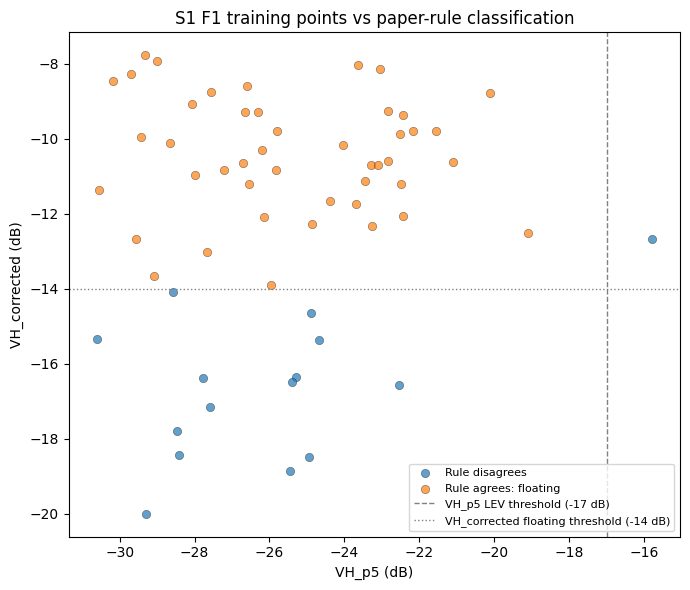


F1 point counts by rule agreement:
paper_rule_agrees_floating
True     45
False    15
Name: count, dtype: int64


In [ ]:
def plot_s1_f1_paper_rule_disagreement(df, output_path=None):
    if 'paper_rule_label' not in df.columns:
        print('No paper_rule_label in S1 dataframe; skipping plot.')
        return None
    if 'VH_p5' not in df.columns or 'VH_corrected' not in df.columns:
        print('Missing VH_p5 or VH_corrected; skipping plot.')
        return None

    f1_df = df[df[LABEL_COLUMN].eq('F1')].copy()
    if f1_df.empty:
        print('No F1 points in S1 dataframe; skipping plot.')
        return None
    f1_df['paper_rule_agrees_floating'] = f1_df['paper_rule_label'].eq('Floating plants')

    fig, ax = plt.subplots(figsize=(7, 6))
    for agrees, sub in f1_df.groupby('paper_rule_agrees_floating'):
        ax.scatter(
            sub['VH_p5'], sub['VH_corrected'],
            label=('Rule agrees: floating' if agrees else 'Rule disagrees'),
            alpha=0.7, edgecolor='k', linewidth=0.3
        )
    ax.axvline(-17, color='grey', linestyle='--', linewidth=1, label='VH_p5 LEV threshold (-17 dB)')
    ax.axhline(-14, color='grey', linestyle=':', linewidth=1, label='VH_corrected floating threshold (-14 dB)')
    ax.set_xlabel('VH_p5 (dB)')
    ax.set_ylabel('VH_corrected (dB)')
    ax.set_title('S1 F1 training points vs paper-rule classification')
    ax.legend(loc='lower right', fontsize=8)
    fig.tight_layout()

    if output_path is not None:
        fig.savefig(output_path, dpi=150)
        print('Saved diagnostic plot:', output_path)

    plt.show()
    plt.close(fig)

    counts = f1_df['paper_rule_agrees_floating'].value_counts()
    print('\nF1 point counts by rule agreement:')
    print(counts)
    return f1_df


s1_f1_diag_df = plot_s1_f1_paper_rule_disagreement(
    s1_clean_df,
    output_path=LOCAL_OUTPUT_DIR / f'winam_s1_f1_paper_rule_disagreement_{CLASSIFIER_VERSION}.png'
)

## 4. FeatureCollection helpers

In [ ]:
def python_scalar(x):
    if pd.isna(x):
        return None
    if isinstance(x, (np.integer,)):
        return int(x)
    if isinstance(x, (np.floating,)):
        return float(x)
    return x


def parse_geo_to_ee_geometry(geo_value):
    geom = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
    if isinstance(geom, dict) and geom.get('type') == 'Point':
        return ee.Geometry.Point(geom['coordinates'])
    if isinstance(geom, dict) and geom.get('type') == 'Feature':
        return ee.Geometry(geom['geometry'])
    return ee.Geometry(geom)


def extract_lonlat_from_geo(geo_value):
    """Return (lon, lat) from a CSV .geo cell. Used for spatial block CV."""
    geom = json.loads(geo_value) if isinstance(geo_value, str) else geo_value
    if isinstance(geom, dict):
        if geom.get('type') == 'Point':
            lon, lat = geom['coordinates'][:2]
            return float(lon), float(lat)
        if geom.get('type') == 'Feature':
            lon, lat = geom['geometry']['coordinates'][:2]
            return float(lon), float(lat)
    coords = geom['coordinates']
    return float(coords[0]), float(coords[1])


def df_to_ee_fc(df, predictor_cols=None):
    if predictor_cols is None:
        predictor_cols = []
    base_props = [CLASS_COLUMN, LABEL_COLUMN, 'paper_rule_class', 'paper_rule_label',
                  'Location', 'Date', 'date']
    property_cols = [col for col in predictor_cols + base_props if col in df.columns]
    features = []
    for _, row in df.iterrows():
        geom = parse_geo_to_ee_geometry(row['.geo'])
        props = {col: python_scalar(row[col]) for col in property_cols if col in row.index}
        features.append(ee.Feature(geom, props))
    return ee.FeatureCollection(features)

## 5. S2 FeatureCollection from existing CSV predictors

In [ ]:
S2_SUPERVISED_PREDICTORS_CANDIDATE = [
    'AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI',
    'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2'
]


def keep_existing_predictors(df, candidate_predictors, name):
    predictors = [col for col in candidate_predictors if col in df.columns]
    missing = [col for col in candidate_predictors if col not in df.columns]
    print(f'{name} predictors used:', predictors)
    if missing:
        print(f'{name} predictors missing/skipped:', missing)
    return predictors


S2_PREDICTORS = keep_existing_predictors(s2_clean_df, S2_SUPERVISED_PREDICTORS_CANDIDATE, 'S2')
s2_clean_df = s2_clean_df.dropna(subset=S2_PREDICTORS + [CLASS_COLUMN, '.geo']).copy()
s2_fc = df_to_ee_fc(s2_clean_df, S2_PREDICTORS)
print('Usable S2 rows:', len(s2_clean_df))
print('S2 FC size:', s2_fc.size().getInfo())

print('\nS2 final class counts:')
print(s2_clean_df[CLASS_COLUMN].map(S2_CLASS_NAMES).value_counts())

S2 predictors used: ['AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI', 'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2']
Usable S2 rows: 238
S2 FC size: 238

S2 final class counts:
class
Open water         61
Floating plants    60
Surface algae      60
LEV                57
Name: count, dtype: int64


## 6. S1 exact SCC preprocessing

In [ ]:
S1_REF_ANGLE_DEGREES = 38.0
S1_COMPOSITE_START = '2015-11-18'
S1_COMPOSITE_END = '2021-06-01'
S1_PREDICTORS = ['VH_p5', 'VH_corrected', 'VH_smooth']


def add_s1_predictors_exact_scc(img, ref_angle_degrees=S1_REF_ANGLE_DEGREES):
    theta = img.select('angle').multiply(np.pi / 180.0)
    theta_ref = ee.Image.constant(ref_angle_degrees * np.pi / 180.0)
    correction_db = theta_ref.cos().pow(2).divide(theta.cos().pow(2)).log10().multiply(10.0)
    vh_corrected = img.select('VH').add(correction_db).rename('VH_corrected').toFloat()
    vv_corrected = img.select('VV').add(correction_db).rename('VV_corrected').toFloat()
    kernel_5x5 = ee.Kernel.square(radius=2, units='pixels', normalize=False)
    vh_smooth = vh_corrected.focal_median(kernel=kernel_5x5).rename('VH_smooth')
    vv_smooth = vv_corrected.focal_median(kernel=kernel_5x5).rename('VV_smooth')
    return img.addBands([vh_corrected, vv_corrected, vh_smooth, vv_smooth], overwrite=True)


def get_s1_collection(start_date, end_date, aoi):
    return (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .map(add_s1_predictors_exact_scc)
    )


def get_s1_vh_p5(aoi):
    return (
        get_s1_collection(S1_COMPOSITE_START, S1_COMPOSITE_END, aoi)
        .select('VH_corrected')
        .reduce(ee.Reducer.percentile([5]))
        .rename('VH_p5')
    )


def get_s1_predictor_image_for_period(start_date, end_date, aoi, verbose=True):
    collection = get_s1_collection(start_date, end_date, aoi)
    if verbose:
        print('S1 image count:', collection.size().getInfo())
    return collection.median().addBands(get_s1_vh_p5(aoi)).select(S1_PREDICTORS).clip(aoi)

## 7. S1 training-point re-sampling with exact SCC

In [ ]:
S1_TRAINING_DAY_WINDOW = 1


def df_to_points_for_date(df, date_string):
    sub = df[df['date'].eq(date_string)].copy()
    return df_to_ee_fc(sub, predictor_cols=[])


def resample_s1_training_by_date(df, aoi, day_window=1):
    date_values = sorted(df['date'].dropna().unique())
    sampled_collections = []
    skipped_dates = []
    for date_string in date_values:
        start = ee.Date(date_string)
        end = start.advance(day_window, 'day')
        collection = get_s1_collection(start, end, aoi)
        count = collection.size().getInfo()
        print(f'Sampling S1 date {date_string} | images in window: {count}')
        if count == 0:
            skipped_dates.append(date_string)
            continue
        points_for_date = df_to_points_for_date(df, date_string)
        predictor_img = collection.median().addBands(get_s1_vh_p5(aoi)).select(S1_PREDICTORS)
        sampled = predictor_img.sampleRegions(
            collection=points_for_date,
            properties=[p for p in [CLASS_COLUMN, LABEL_COLUMN, 'paper_rule_class',
                                    'paper_rule_label', 'Location', 'Date', 'date']
                        if p in df.columns],
            scale=10,
            geometries=True,
            tileScale=16
        )
        sampled_collections.append(sampled)
    if not sampled_collections:
        raise RuntimeError('No S1 training dates had imagery. Increase S1_TRAINING_DAY_WINDOW.')
    return ee.FeatureCollection(sampled_collections).flatten(), skipped_dates

## 8. Spatial block CV, repeated splits, and tie-aware production model selection

This replaces the previous single `train_test_split` evaluation. For each candidate classifier, we:

1. Assign each training row to a spatial block defined by binning its longitude and latitude to `SPATIAL_BLOCK_DEGREES`.
2. Run `GroupKFold(n_splits=SPATIAL_CV_N_SPLITS)` so the test fold's spatial blocks are disjoint from the train fold's spatial blocks.
3. Repeat this `SPATIAL_CV_N_REPEATS` times with different shuffles of the block-to-fold assignment, accumulating metrics.
4. Report mean ± std for every metric.

The selected production model is then the most parsimonious model whose mean score is within 1 std of the best.

In [ ]:
def ee_fc_to_df_with_lonlat(fc):
    """Like geemap.ee_to_df but preserves lon/lat from each point geometry."""
    info = fc.getInfo()
    rows = []
    for feat in info['features']:
        props = dict(feat['properties'])
        geom = feat.get('geometry') or {}
        if geom.get('type') == 'Point':
            props['lon'], props['lat'] = geom['coordinates'][:2]
        else:
            props['lon'], props['lat'] = float('nan'), float('nan')
        rows.append(props)
    return pd.DataFrame(rows)

def assign_spatial_blocks(df, block_degrees=SPATIAL_BLOCK_DEGREES):
    """Add lon/lat and a spatial block id to each training row."""
    df = df.copy()
    if 'lon' not in df.columns or 'lat' not in df.columns:
        if '.geo' not in df.columns:
            raise ValueError(
                'Cannot assign spatial blocks without lon/lat or .geo columns. '
                'For S1 training data sampled via GEE, use ee_fc_to_df_with_lonlat '
                'instead of geemap.ee_to_df.'
            )
        lonlat = df['.geo'].apply(extract_lonlat_from_geo)
        df['lon'] = lonlat.apply(lambda t: t[0])
        df['lat'] = lonlat.apply(lambda t: t[1])

    lon_bin = np.floor(df['lon'].astype(float) / block_degrees).astype(np.int64)
    lat_bin = np.floor(df['lat'].astype(float) / block_degrees).astype(np.int64)
    df['spatial_block'] = (lon_bin * 100000 + lat_bin).astype(np.int64)
    return df

def _safe_stratify(y, test_fraction):
    counts = pd.Series(y).value_counts()
    n_classes = counts.size
    if n_classes <= 1:
        return None
    if counts.min() < 2:
        return None
    if int(np.ceil(len(y) * test_fraction)) < n_classes:
        return None
    return y


def _enabled_candidate_names():
    if CLASSIFIER_CANDIDATE_NAMES is None:
        return None
    return set(CLASSIFIER_CANDIDATE_NAMES)


def make_candidate_classifiers(seed=42, include_svm=False):
    candidates = {
        'Random Forest': RandomForestClassifier(
            n_estimators=500, max_features='sqrt', min_samples_leaf=1, bootstrap=True,
            random_state=seed, n_jobs=-1
        ),
        'Class-weighted RF': RandomForestClassifier(
            n_estimators=500, max_features='sqrt', min_samples_leaf=1, bootstrap=True,
            class_weight='balanced', random_state=seed, n_jobs=-1
        ),
        'Extra Trees': ExtraTreesClassifier(
            n_estimators=500, max_features='sqrt', min_samples_leaf=1,
            class_weight='balanced', random_state=seed, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=seed
        ),
        'Hist Gradient Boosting': HistGradientBoostingClassifier(
            learning_rate=0.05, max_iter=300, max_leaf_nodes=31,
            l2_regularization=0.01, random_state=seed
        ),
        'Logistic Regression baseline': make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=3000, class_weight='balanced', solver='lbfgs')
        ),
    }
    if include_svm:
        candidates['RBF SVM'] = make_pipeline(
            StandardScaler(),
            SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                probability=True, random_state=seed)
        )
    enabled = _enabled_candidate_names()
    if enabled is not None:
        candidates = {name: model for name, model in candidates.items() if name in enabled}
    if not candidates:
        raise ValueError('No classifier candidates are enabled. Check CLASSIFIER_CANDIDATE_NAMES.')
    return candidates


def _score_split(model, X_train, y_train, X_test, y_test, labels):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    p, r, floating_f1, support = precision_recall_fscore_support(
        y_test, y_pred, labels=[FLOATING_CLASS_CODE], zero_division=0
    )
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'kappa': cohen_kappa_score(y_test, y_pred, labels=labels),
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
        'floating_precision': p[0],
        'floating_recall': r[0],
        'floating_f1': floating_f1[0],
        'floating_support': int(support[0]),
    }


def evaluate_with_spatial_cv(
    X, y, groups, candidates, labels,
    n_splits=SPATIAL_CV_N_SPLITS, n_repeats=SPATIAL_CV_N_REPEATS,
    random_state=SPATIAL_CV_RANDOM_STATE, sensor_name='Sensor'
):
    """Run GroupKFold n_repeats times with shuffled group order; aggregate per-model metrics."""
    rng = np.random.default_rng(random_state)
    unique_groups = np.unique(groups)
    if len(unique_groups) < n_splits:
        raise ValueError(
            f'{sensor_name}: only {len(unique_groups)} spatial blocks but n_splits={n_splits}. '
            'Reduce SPATIAL_BLOCK_DEGREES (smaller blocks) or n_splits.'
        )

    rows = []
    for model_name, model_template in candidates.items():
        per_fold_metrics = []
        for repeat in range(n_repeats):
            # Shuffle groups, then assign each row to a fold based on its (shuffled) group order.
            shuffled = rng.permutation(unique_groups)
            group_to_fold = {g: i % n_splits for i, g in enumerate(shuffled)}
            fold_assignments = np.array([group_to_fold[g] for g in groups])
            for fold in range(n_splits):
                test_idx = np.where(fold_assignments == fold)[0]
                train_idx = np.where(fold_assignments != fold)[0]
                if len(test_idx) == 0 or len(train_idx) == 0:
                    continue
                # Skip folds where any class is missing from train (model can still predict, but
                # floating_f1 becomes uninformative; we keep it and let zero_division=0 handle it).
                model = clone(model_template)
                metrics = _score_split(
                    model,
                    X[train_idx], y[train_idx],
                    X[test_idx], y[test_idx],
                    labels
                )
                metrics['repeat'] = repeat
                metrics['fold'] = fold
                per_fold_metrics.append(metrics)

        per_fold_df = pd.DataFrame(per_fold_metrics)
        agg = {'sensor': sensor_name, 'model': model_name,
               'n_folds_evaluated': len(per_fold_df)}
        for col in ['accuracy', 'balanced_accuracy', 'kappa', 'macro_f1', 'weighted_f1',
                    'floating_precision', 'floating_recall', 'floating_f1']:
            agg[f'{col}_mean'] = per_fold_df[col].mean()
            agg[f'{col}_std'] = per_fold_df[col].std()
        rows.append(agg)

    return pd.DataFrame(rows)


def evaluate_with_random_split(
    X, y, candidates, labels, sensor_name='Sensor', seed=42, train_fraction=0.7
):
    """Legacy i.i.d. random split, kept as a diagnostic to compare against spatial CV."""
    test_fraction = 1.0 - train_fraction
    stratify = _safe_stratify(y, test_fraction)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, train_size=train_fraction, random_state=seed, stratify=stratify
    )
    rows = []
    for model_name, model_template in candidates.items():
        model = clone(model_template)
        metrics = _score_split(model, X_train, y_train, X_test, y_test, labels)
        metrics.update({'sensor': sensor_name, 'model': model_name,
                        'train_rows': len(y_train), 'test_rows': len(y_test)})
        rows.append(metrics)
    return pd.DataFrame(rows)


def select_production_model_tie_aware(spatial_results_df, preferred_metric=MODEL_SELECTION_METRIC,
                                       tie_tolerance_std=TIE_TOLERANCE_STD,
                                       parsimony_order=PRODUCTION_PARSIMONY_ORDER,
                                       allowed_models=PRODUCTION_CLASSIFIER_CANDIDATE_NAMES):
    """Pick the production model: among models whose mean score is within
    tie_tolerance_std * std of the leader, return the most parsimonious."""
    df = spatial_results_df.copy()
    if allowed_models is not None:
        df = df[df['model'].isin(set(allowed_models))].copy()
        if df.empty:
            print('Warning: PRODUCTION_CLASSIFIER_CANDIDATE_NAMES excludes every evaluated model. '
                  'Falling back to all evaluated models.')
            df = spatial_results_df.copy()

    mean_col = f'{preferred_metric}_mean'
    std_col = f'{preferred_metric}_std'
    if mean_col not in df.columns:
        raise ValueError(f'Preferred metric column {mean_col} not in results.')

    df = df.sort_values(mean_col, ascending=False).reset_index(drop=True)
    leader_mean = df.loc[0, mean_col]
    leader_std = df.loc[0, std_col]
    threshold = leader_mean - tie_tolerance_std * leader_std
    print(f"Production selection: leader mean={leader_mean:.4f}, std={leader_std:.4f}, "
          f"tie threshold (mean >= {threshold:.4f}):")
    tied = df[df[mean_col] >= threshold].copy()
    display(tied[['model', mean_col, std_col]])

    # Pick the most parsimonious among tied models.
    for candidate in parsimony_order:
        if candidate in set(tied['model']):
            print(f"Selected production model by parsimony tiebreak: {candidate}")
            return candidate
    # Fallback: highest mean score.
    fallback = df.loc[0, 'model']
    print(f"Parsimony order did not match any tied model; falling back to leader: {fallback}")
    return fallback


def model_feature_importance(model, predictors):
    estimator = model
    if hasattr(model, 'named_steps'):
        estimator = list(model.named_steps.values())[-1]
    if hasattr(estimator, 'feature_importances_'):
        importance = estimator.feature_importances_
        return pd.DataFrame({
            'predictor': predictors,
            'importance': importance,
            'importance_type': 'tree_feature_importance'
        }).sort_values('importance', ascending=False)
    if hasattr(estimator, 'coef_'):
        coef = np.asarray(estimator.coef_)
        if coef.ndim == 1:
            importance = np.abs(coef)
        else:
            importance = np.mean(np.abs(coef), axis=0)
        return pd.DataFrame({
            'predictor': predictors,
            'importance': importance,
            'importance_type': 'mean_absolute_standardised_coefficient'
        }).sort_values('importance', ascending=False)
    print('Selected model does not expose built-in feature importances.')
    return pd.DataFrame(columns=['predictor', 'importance', 'importance_type'])

### 8b. Run spatial CV, optional random-split diagnostic, train selected model on all data

In [ ]:
def train_with_spatial_cv(df, predictors, class_names=None, sensor_name='Sensor', seed=42):
    missing = [col for col in predictors + [CLASS_COLUMN] if col not in df.columns]
    if missing:
        raise ValueError(f'{sensor_name} training data is missing columns: {missing}')

    df = assign_spatial_blocks(df, block_degrees=SPATIAL_BLOCK_DEGREES)
    df = df.dropna(subset=predictors + [CLASS_COLUMN, 'spatial_block']).copy()
    if df.empty:
        raise ValueError(f'{sensor_name}: no usable rows after dropping NaNs.')

    X = df[predictors].astype(np.float32).to_numpy()
    y = df[CLASS_COLUMN].astype(int).to_numpy()
    groups = df['spatial_block'].to_numpy()
    labels = sorted(class_names.keys()) if class_names else sorted(np.unique(y))

    n_blocks = len(np.unique(groups))
    print(f'{sensor_name}: {len(df)} rows across {n_blocks} spatial blocks '
          f'(block size ~{SPATIAL_BLOCK_DEGREES} degrees)')

    candidates = make_candidate_classifiers(seed=seed, include_svm=INCLUDE_SVM_CANDIDATE)

    print(f'\n=== {sensor_name}: spatial block CV ({SPATIAL_CV_N_SPLITS} splits x '
          f'{SPATIAL_CV_N_REPEATS} repeats) ===')
    spatial_results = evaluate_with_spatial_cv(
        X, y, groups, candidates, labels,
        n_splits=SPATIAL_CV_N_SPLITS, n_repeats=SPATIAL_CV_N_REPEATS,
        random_state=SPATIAL_CV_RANDOM_STATE, sensor_name=sensor_name
    )
    spatial_results = spatial_results.sort_values(
        f'{MODEL_SELECTION_METRIC}_mean', ascending=False
    ).reset_index(drop=True)
    print(f'\n{sensor_name} spatial CV results, sorted by {MODEL_SELECTION_METRIC}_mean:')
    display(spatial_results)

    random_results = None
    if ALSO_RUN_RANDOM_CV_FOR_COMPARISON:
        print(f'\n=== {sensor_name}: legacy random split (for comparison only) ===')
        random_results = evaluate_with_random_split(
            X, y, candidates, labels, sensor_name=sensor_name, seed=seed
        )
        random_results = random_results.sort_values(MODEL_SELECTION_METRIC, ascending=False)
        display(random_results)

    if USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION:
        selected_model_name = select_production_model_tie_aware(spatial_results)
    else:
        selected_model_name = 'Random Forest'
        print(f'USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION is False; '
              f'forcing {selected_model_name}.')

    if selected_model_name not in candidates:
        raise ValueError(f"Selected model '{selected_model_name}' not in candidate set.")

    final_model = clone(candidates[selected_model_name])
    final_model.fit(X, y)
    importance_df = model_feature_importance(final_model, predictors)
    print(f'\nFinal {sensor_name} model trained on all usable rows: {len(y)}')
    print('Selected model for raster classification:', selected_model_name)
    if not importance_df.empty:
        print('\nVariable importance / coefficients:')
        display(importance_df)

    return final_model, importance_df, df, spatial_results, random_results, selected_model_name


def save_local_classifier_bundle(model, predictors, class_names, model_path,
                                  importance_df=None, model_name=None,
                                  spatial_results=None, random_results=None):
    bundle = {
        'model': model,
        'model_name': model_name,
        'predictors': list(predictors),
        'class_names': dict(class_names),
        'classifier_version': CLASSIFIER_VERSION,
        'model_selection_metric': MODEL_SELECTION_METRIC,
        'use_selected_model_for_raster_classification': USE_SELECTED_MODEL_FOR_RASTER_CLASSIFICATION,
        'production_classifier_candidate_names': PRODUCTION_CLASSIFIER_CANDIDATE_NAMES,
        'spatial_block_degrees': SPATIAL_BLOCK_DEGREES,
        'spatial_cv_n_splits': SPATIAL_CV_N_SPLITS,
        'spatial_cv_n_repeats': SPATIAL_CV_N_REPEATS,
        'tie_tolerance_std': TIE_TOLERANCE_STD,
        'parsimony_order': PRODUCTION_PARSIMONY_ORDER,
    }
    if importance_df is not None:
        bundle['feature_importance'] = importance_df.to_dict(orient='records')
    if spatial_results is not None:
        bundle['spatial_cv_results'] = spatial_results.to_dict(orient='records')
    if random_results is not None:
        bundle['random_split_results'] = random_results.to_dict(orient='records')
    joblib.dump(bundle, model_path)
    print('Saved local classifier bundle:', model_path)


def load_local_classifier_bundle(model_path, expected_predictors, model_name):
    if not Path(model_path).exists():
        raise FileNotFoundError(f'Could not find saved {model_name} model: {model_path}')
    bundle = joblib.load(model_path)
    predictors = bundle.get('predictors')
    if predictors != list(expected_predictors):
        raise ValueError(
            f'{model_name} predictor mismatch.\nExpected: {list(expected_predictors)}\n'
            f'Loaded:   {predictors}'
        )
    print(f'Loaded saved local {model_name} classifier bundle:', model_path)
    print('Loaded model type/name:', bundle.get('model_name', type(bundle["model"]).__name__))
    return bundle['model'], bundle


if USE_SAVED_LOCAL_CLASSIFIERS:
    s2_classifier_final, s2_model_bundle = load_local_classifier_bundle(
        S2_LOCAL_MODEL_PATH, S2_PREDICTORS, 'S2')
    s1_classifier_final, s1_model_bundle = load_local_classifier_bundle(
        S1_LOCAL_MODEL_PATH, S1_PREDICTORS, 'S1')
    s2_selected_model_name = s2_model_bundle.get('model_name', 'Saved classifier')
    s1_selected_model_name = s1_model_bundle.get('model_name', 'Saved classifier')
    s2_spatial_results = pd.DataFrame(s2_model_bundle.get('spatial_cv_results', []))
    s1_spatial_results = pd.DataFrame(s1_model_bundle.get('spatial_cv_results', []))
    s2_random_results = pd.DataFrame(s2_model_bundle.get('random_split_results', []))
    s1_random_results = pd.DataFrame(s1_model_bundle.get('random_split_results', []))
    s2_importance_df = pd.DataFrame(s2_model_bundle.get('feature_importance', []))
    s1_importance_df = pd.DataFrame(s1_model_bundle.get('feature_importance', []))
    s1_fc_exact = None
    s1_training_df_local = None
else:
    (s2_classifier_final, s2_importance_df, s2_training_df_local,
     s2_spatial_results, s2_random_results, s2_selected_model_name) = train_with_spatial_cv(
        s2_clean_df, S2_PREDICTORS, class_names=S2_CLASS_NAMES, sensor_name='S2 Route B'
    )

    s1_fc_exact, skipped_s1_dates = resample_s1_training_by_date(
        s1_clean_df, winam, S1_TRAINING_DAY_WINDOW
    )
    print('\nExact SCC-resampled S1 training rows:', s1_fc_exact.size().getInfo())
    if skipped_s1_dates:
        print('Skipped S1 dates:', skipped_s1_dates)
    s1_training_df_local = ee_fc_to_df_with_lonlat(s1_fc_exact)
    print('\nS1 class counts after SCC re-sampling:')
    display(s1_training_df_local[CLASS_COLUMN].map(S1_CLASS_NAMES).value_counts())

    (s1_classifier_final, s1_importance_df, s1_training_df_local,
     s1_spatial_results, s1_random_results, s1_selected_model_name) = train_with_spatial_cv(
        s1_training_df_local, S1_PREDICTORS, class_names=S1_CLASS_NAMES, sensor_name='S1 Route B SCC'
    )

    spatial_csv = LOCAL_OUTPUT_DIR / f'winam_classifier_spatial_cv_{CLASSIFIER_VERSION}.csv'
    pd.concat([s2_spatial_results.assign(stage='spatial_cv'),
               s1_spatial_results.assign(stage='spatial_cv')], ignore_index=True).to_csv(spatial_csv, index=False)
    print('Saved spatial CV comparison table:', spatial_csv)

    if s2_random_results is not None and s1_random_results is not None:
        random_csv = LOCAL_OUTPUT_DIR / f'winam_classifier_random_split_{CLASSIFIER_VERSION}.csv'
        pd.concat([s2_random_results, s1_random_results], ignore_index=True).to_csv(random_csv, index=False)
        print('Saved random-split diagnostic table:', random_csv)

    if SAVE_LOCAL_CLASSIFIERS:
        save_local_classifier_bundle(
            s2_classifier_final, S2_PREDICTORS, S2_CLASS_NAMES, S2_LOCAL_MODEL_PATH,
            s2_importance_df, model_name=s2_selected_model_name,
            spatial_results=s2_spatial_results, random_results=s2_random_results
        )
        save_local_classifier_bundle(
            s1_classifier_final, S1_PREDICTORS, S1_CLASS_NAMES, S1_LOCAL_MODEL_PATH,
            s1_importance_df, model_name=s1_selected_model_name,
            spatial_results=s1_spatial_results, random_results=s1_random_results
        )

# Backward-compatible aliases used by later cells.
s2_rf_final = s2_classifier_final
s1_rf_final = s1_classifier_final


if SAVE_CLASSIFIER_METADATA:
    metadata = {
        'classifier_version': CLASSIFIER_VERSION,
        'ee_project': EE_PROJECT,
        's2_local_model_path': str(S2_LOCAL_MODEL_PATH),
        's1_local_model_path': str(S1_LOCAL_MODEL_PATH),
        's2_selected_model_name': s2_selected_model_name,
        's1_selected_model_name': s1_selected_model_name,
        'model_selection_metric': MODEL_SELECTION_METRIC,
        'spatial_block_degrees': SPATIAL_BLOCK_DEGREES,
        'spatial_cv_n_splits': SPATIAL_CV_N_SPLITS,
        'spatial_cv_n_repeats': SPATIAL_CV_N_REPEATS,
        'tie_tolerance_std': TIE_TOLERANCE_STD,
        'parsimony_order': PRODUCTION_PARSIMONY_ORDER,
        'include_svm_candidate': INCLUDE_SVM_CANDIDATE,
        'production_classifier_candidate_names': PRODUCTION_CLASSIFIER_CANDIDATE_NAMES,
        'write_probability_raster': WRITE_PROBABILITY_RASTER,
        'confidence_thresholds': CONFIDENCE_THRESHOLDS,
        'reject_drive_collision_duplicates': REJECT_DRIVE_COLLISION_DUPLICATES,
        's2_predictors': S2_PREDICTORS,
        's1_predictors': S1_PREDICTORS,
        's2_class_names': S2_CLASS_NAMES,
        's1_class_names': S1_CLASS_NAMES,
        'aoi': [34, -0.55, 34.9, 0],
        'notes': 'Spatial block CV, repeated splits, tie-aware selection, probability rasters, '
                 'and Drive duplicate-tile guard.'
    }
    metadata_path = LOCAL_OUTPUT_DIR / f'winam_classifier_metadata_{CLASSIFIER_VERSION}.json'
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print('Saved classifier metadata:', metadata_path)

S2 Route B: 238 rows across 25 spatial blocks (block size ~0.1 degrees)

=== S2 Route B: spatial block CV (5 splits x 10 repeats) ===

S2 Route B spatial CV results, sorted by floating_f1_mean:


,sensor,model,n_folds_evaluated,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,kappa_mean,kappa_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,floating_precision_mean,floating_precision_std,floating_recall_mean,floating_recall_std,floating_f1_mean,floating_f1_std
0,S2 Route B,Logistic Regression baseline,50,0.973334,0.024143,0.969011,0.030487,0.963095,0.033780,0.969816,0.028988,0.973172,0.024239,0.971776,0.058247,0.951157,0.077470,0.959215,0.055669
1,S2 Route B,Random Forest,50,0.970559,0.020538,0.969590,0.022047,0.959835,0.027691,0.969073,0.021187,0.970605,0.020436,0.936058,0.149040,0.933145,0.150936,0.931654,0.141693
2,S2 Route B,Hist Gradient Boosting,50,0.958819,0.020831,0.956670,0.026265,0.943401,0.028593,0.955811,0.023840,0.958876,0.020791,0.920156,0.088183,0.947651,0.070000,0.929290,0.051821
3,S2 Route B,Class-weighted RF,50,0.966557,0.025009,0.961857,0.040463,0.954264,0.034231,0.959691,0.042615,0.966467,0.024862,0.916756,0.162722,0.938058,0.146638,0.923499,0.146691
4,S2 Route B,Extra Trees,50,0.964617,0.025755,0.964576,0.026412,0.951736,0.034781,0.956891,0.041874,0.965233,0.025476,0.919880,0.161658,0.926318,0.148833,0.919233,0.145149
5,S2 Route B,Gradient Boosting,50,0.955281,0.022636,0.951399,0.029440,0.938654,0.031017,0.951333,0.028443,0.955360,0.022454,0.900076,0.154510,0.928079,0.151307,0.910990,0.144680



=== S2 Route B: legacy random split (for comparison only) ===


,accuracy,balanced_accuracy,kappa,macro_f1,weighted_f1,floating_precision,floating_recall,floating_f1,floating_support,sensor,model,train_rows,test_rows
5,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18,S2 Route B,Logistic Regression baseline,166,72
2,0.986111,0.986111,0.981477,0.985714,0.986111,1.000000,0.944444,0.971429,18,S2 Route B,Extra Trees,166,72
3,0.958333,0.959064,0.944444,0.958668,0.958708,1.000000,0.944444,0.971429,18,S2 Route B,Gradient Boosting,166,72
0,0.972222,0.972222,0.962953,0.971825,0.972222,0.944444,0.944444,0.944444,18,S2 Route B,Random Forest,166,72
1,0.972222,0.972222,0.962953,0.971825,0.972222,0.944444,0.944444,0.944444,18,S2 Route B,Class-weighted RF,166,72
4,0.958333,0.959064,0.944459,0.958323,0.958719,0.944444,0.944444,0.944444,18,S2 Route B,Hist Gradient Boosting,166,72


Production selection: leader mean=0.9592, std=0.0557, tie threshold (mean >= 0.9035):


...

Production selection: leader mean=0.9511, std=0.0347, tie threshold (mean >= 0.9164):


,model,floating_f1_mean,floating_f1_std
0,Logistic Regression baseline,0.951130,0.034740
1,Extra Trees,0.939501,0.051652
2,Class-weighted RF,0.937910,0.055067
3,Random Forest,0.930985,0.068180
4,Hist Gradient Boosting,0.917466,0.050741


Selected production model by parsimony tiebreak: Logistic Regression baseline

Final S1 Route B SCC model trained on all usable rows: 236
Selected model for raster classification: Logistic Regression baseline

Variable importance / coefficients:


,predictor,importance,importance_type
0,VH_p5,1.571804,mean_absolute_standardised_coefficient
1,VH_corrected,1.126347,mean_absolute_standardised_coefficient
2,VH_smooth,0.716049,mean_absolute_standardised_coefficient


Saved spatial CV comparison table: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_spatial_cv_route_b_s1_scc_spatialcv_proba_v3.csv
Saved random-split diagnostic table: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_random_split_route_b_s1_scc_spatialcv_proba_v3.csv
Saved local classifier bundle: /content/drive/MyDrive/Winam_RF_Training_Data/models/winam_s2_model_route_b_s1_scc_spatialcv_proba_v3.joblib
Saved local classifier bundle: /content/drive/MyDrive/Winam_RF_Training_Data/models/winam_s1_model_route_b_s1_scc_spatialcv_proba_v3.joblib
Saved classifier metadata: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_classifier_metadata_route_b_s1_scc_spatialcv_proba_v3.json


## 9. S2 predictor image builder

In [ ]:
S2_COMPOSITE_START = '2017-04-01'
S2_COMPOSITE_END = '2021-06-01'


def mask_s2_sr(img):
    scl = img.select('SCL')
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)).And(scl.neq(11))
    return img.updateMask(mask)


def add_s2_predictors(img):
    bands = img.select(
        ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8A', 'B8', 'B11', 'B12'],
        ['B',  'G',  'R',  'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2']
    ).toFloat()
    ndvi = bands.normalizedDifference(['NIR', 'R']).rename('NDVI')
    ndmi = bands.normalizedDifference(['NIR', 'SWIR']).rename('NDMI')
    mndwi = bands.normalizedDifference(['G', 'SWIR']).rename('MNDWI')
    awei = bands.expression(
        'B + 2.5 * G - 1.5 * (NIR + SWIR) - 0.25 * SWIR2',
        {'B': bands.select('B'), 'G': bands.select('G'), 'NIR': bands.select('NIR'),
         'SWIR': bands.select('SWIR'), 'SWIR2': bands.select('SWIR2')}
    ).rename('AWEI')
    aweinsh = bands.expression(
        '4 * (G - SWIR) - (0.25 * NIR + 2.75 * SWIR2)',
        {'G': bands.select('G'), 'NIR': bands.select('NIR'),
         'SWIR': bands.select('SWIR'), 'SWIR2': bands.select('SWIR2')}
    ).rename('AWEInsh')
    return bands.addBands([ndvi, ndmi, mndwi, awei, aweinsh])


def get_s2_collection(start_date, end_date, aoi, cloud_pct=70):
    return (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cloud_pct))
        .map(mask_s2_sr)
        .map(add_s2_predictors)
    )


def get_s2_awei_p95(aoi):
    return (get_s2_collection(S2_COMPOSITE_START, S2_COMPOSITE_END, aoi)
            .select('AWEI').reduce(ee.Reducer.percentile([95])).rename('AWEI_p95'))


def get_s2_predictor_image(start_date, end_date, aoi, cloud_pct=70, verbose=True):
    collection = get_s2_collection(start_date, end_date, aoi, cloud_pct)
    if verbose:
        print('S2 image count:', collection.size().getInfo())
    return collection.median().addBands(get_s2_awei_p95(aoi)).select(S2_PREDICTORS).clip(aoi)

## 10. Water mask and local rule-classifier helpers

In [ ]:
APPLY_JRC_WATER_MASK = True
JRC_OCCURRENCE_THRESHOLD = 5

APPLY_S1_RF_CONSTRAINT = False
S1_RF_VH_THRESHOLD = -14
S1_RF_LEV_THRESHOLD = -17

APPLY_LOCAL_S1_PATCH_FILTER = False
S1_LOCAL_MIN_PATCH_PIXELS = 200


def get_jrc_water_mask(aoi, occurrence_threshold=5):
    return ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence').gte(occurrence_threshold).clip(aoi)


def apply_optional_water_mask_to_predictor_image(predictor_img, aoi):
    if APPLY_JRC_WATER_MASK:
        return predictor_img.updateMask(get_jrc_water_mask(aoi, JRC_OCCURRENCE_THRESHOLD))
    return predictor_img


def classify_s2_rules_array(band_arrays, valid_mask, nodata_value=NODATA_VALUE):
    required = ['AWEI_p95', 'AWEI', 'NDMI']
    missing = [band for band in required if band not in band_arrays]
    if missing:
        raise ValueError(f'S2 rule classification needs missing bands: {missing}')
    awei_p95 = band_arrays['AWEI_p95']
    awei = band_arrays['AWEI']
    ndmi = band_arrays['NDMI']
    classified = np.full(valid_mask.shape, nodata_value, dtype=np.uint8)
    classified[valid_mask] = 1
    valid_waterbody = valid_mask & (awei_p95 >= 0)
    classified[valid_waterbody & (awei >= 0)] = 0
    classified[valid_waterbody & (awei < 0) & (ndmi >= 0.63)] = 3
    classified[valid_waterbody & (awei < 0) & (ndmi >= 0.1) & (ndmi < 0.63)] = 2
    return classified


def classify_s1_rules_array(band_arrays, valid_mask, nodata_value=NODATA_VALUE):
    required = ['VH_p5', 'VH_corrected']
    missing = [band for band in required if band not in band_arrays]
    if missing:
        raise ValueError(f'S1 rule classification needs missing bands: {missing}')
    vh_p5 = band_arrays['VH_p5']
    vh = band_arrays['VH_corrected']
    classified = np.full(valid_mask.shape, nodata_value, dtype=np.uint8)
    classified[valid_mask] = 0
    lev = valid_mask & (vh_p5 > -17)
    classified[lev] = 1
    floating = valid_mask & (~lev) & (vh > -14)
    classified[floating] = 2
    return classified


def constrain_s1_rf_with_sar_rules_array(classified, band_arrays, valid_mask,
                                          vh_threshold=S1_RF_VH_THRESHOLD,
                                          lev_threshold=S1_RF_LEV_THRESHOLD):
    required = ['VH_p5', 'VH_corrected']
    missing = [band for band in required if band not in band_arrays]
    if missing:
        raise ValueError(f'S1 RF constraint needs missing bands: {missing}')
    out = classified.copy()
    vh = band_arrays['VH_corrected']
    vh_p5 = band_arrays['VH_p5']
    lev = valid_mask & (vh_p5 > lev_threshold)
    floating_possible = valid_mask & (~lev) & (vh > vh_threshold)
    out[lev] = 1
    out[valid_mask & (out == FLOATING_CLASS_CODE) & (~floating_possible)] = 0
    return out

## 11. Build one target period's unclassified predictor images

In [ ]:
TARGET_START = '2021-02-01'
TARGET_END = '2021-03-01'

# Prefixes for locating already-exported predictor GeoTIFFs in single-period diagnostic mode.
EXPORT_PREFIXES = {
    's2_predictors': f'winam_s2_predictors_{TARGET_START}_to_{TARGET_END}',
    's1_predictors': f'winam_s1_scc_predictors_{TARGET_START}_to_{TARGET_END}',
}

if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_predictor_img = get_s2_predictor_image(TARGET_START, TARGET_END, winam)
    s2_predictor_img = apply_optional_water_mask_to_predictor_image(s2_predictor_img, winam)

    s1_predictor_img = get_s1_predictor_image_for_period(TARGET_START, TARGET_END, winam)
    s1_predictor_img = apply_optional_water_mask_to_predictor_image(s1_predictor_img, winam)

    print('Target-period predictor images built.')
    print('S2 predictor bands:', S2_PREDICTORS)
    print('S1 predictor bands:', S1_PREDICTORS)
    print('Water mask applied in diagnostic image build:', APPLY_JRC_WATER_MASK)
else:
    s2_predictor_img = None
    s1_predictor_img = None
    print('Skipping fixed target-period predictor image build because RUN_SINGLE_PERIOD_WORKFLOW is False.')
    print('The batch post-export workflow below will load existing Batch_Export.ipynb GeoTIFFs from Drive instead.')


S2 image count: 17
S1 image count: 12
Target-period predictor images built.
S2 export bands: ['AWEI_p95', 'AWEI', 'AWEInsh', 'NDMI', 'MNDWI', 'NDVI', 'B', 'G', 'R', 'RE1', 'RE2', 'RE3', 'RE4', 'NIR', 'SWIR', 'SWIR2']
S1 export bands: ['VH_p5', 'VH_corrected', 'VH_smooth']
Water mask applied before export: True


## 12. Visualise maps

In [ ]:
S2_PALETTE = ['2b83ba', 'd9c76c', '1a9850', 'd95f92']
S2_LABELS = ['Open water', 'LEV', 'Floating plants', 'Surface algae']
S1_PALETTE = ['2b83ba', 'd9c76c', '1a9850']

if RUN_SINGLE_PERIOD_WORKFLOW and s2_predictor_img is not None and s1_predictor_img is not None:
    Map = geemap.Map(center=[-0.25, 34.45], zoom=10)
    if all(band in S2_PREDICTORS for band in ['NIR', 'R', 'G']):
        Map.addLayer(s2_predictor_img, {'bands': ['NIR', 'R', 'G'], 'min': 0, 'max': 5000},
                     'S2 false colour predictor')
    if 'NDVI' in S2_PREDICTORS:
        Map.addLayer(s2_predictor_img.select('NDVI'), {'min': -0.2, 'max': 0.8}, 'S2 NDVI', shown=False)
    if 'NDMI' in S2_PREDICTORS:
        Map.addLayer(s2_predictor_img.select('NDMI'), {'min': -0.5, 'max': 1.0}, 'S2 NDMI', shown=False)
    if 'VH_corrected' in S1_PREDICTORS:
        Map.addLayer(s1_predictor_img.select('VH_corrected'), {'min': -25, 'max': 0},
                     'S1 VH corrected predictor')
    if 'VH_smooth' in S1_PREDICTORS:
        Map.addLayer(s1_predictor_img.select('VH_smooth'), {'min': -25, 'max': 0},
                     'S1 VH smooth predictor', shown=False)
    Map.addLayer(winam, {}, 'Adjusted Winam AOI')
    display(Map)
else:
    print('Skipping fixed-period map display because RUN_SINGLE_PERIOD_WORKFLOW is False.')


Map(center=[-0.25, 34.45], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

## 13. Validate existing predictor GeoTIFFs and locate files

This cell actively rejects Google Drive collision-marker files (e.g. `prefix-0000000000-0000000000 (1).tif`) before mosaicking. The previous version silently included them, producing a "4-tile" mosaic from what should have been a 2-tile export.

If you genuinely re-ran `Batch_Export.ipynb` and want to use the newer copies, delete the older ones (the ones *without* `(1)`) from Drive first, then re-run this cell — Drive's collision marker always belongs to the *later* file.

In [ ]:
# Regex matching Google Drive's collision marker, e.g. "foo (1).tif", "foo (12).tif".
_DRIVE_COLLISION_RE = re.compile(r'\s\(\d+\)(\.[^.]+)?$')


def _is_drive_collision_duplicate(path):
    return bool(_DRIVE_COLLISION_RE.search(Path(path).name))


def _is_ee_tiled_export(path, prefix):
    path = Path(path)
    return path.name.startswith(prefix + '-')


def find_exported_geotiffs(prefix, export_dir=GEE_EXPORT_DIR):
    """Locate candidate predictor GeoTIFFs for a Batch_Export.ipynb prefix.

    Earth Engine writes either a single `prefix.tif` or tiled shards
    `prefix-<row>-<col>.tif`. Google Drive may then auto-rename re-downloaded
    copies with " (1)", " (2)" suffixes; those are rejected here when
    REJECT_DRIVE_COLLISION_DUPLICATES is True.
    """
    export_dir = Path(export_dir)
    patterns = [f'{prefix}', f'{prefix}.tif', f'{prefix}.TIF', f'{prefix}.tiff', f'{prefix}.TIFF',
                f'{prefix}-*', f'{prefix}-*.tif', f'{prefix}-*.TIF',
                f'{prefix}-*.tiff', f'{prefix}-*.TIFF']
    matches = []
    for pattern in patterns:
        matches.extend(export_dir.glob(pattern))

    allowed_suffixes = {'.tif', '.tiff', ''}
    deduped = {}
    for p in matches:
        if not p.is_file():
            continue
        if p.suffix.lower() not in allowed_suffixes:
            continue
        deduped.setdefault(p.resolve(), p)
    matches = sorted(deduped.values(), key=lambda p: p.name)

    # NEW: reject Drive duplicate suffixes when configured to do so.
    if REJECT_DRIVE_COLLISION_DUPLICATES:
        rejected = [p for p in matches if _is_drive_collision_duplicate(p)]
        matches = [p for p in matches if not _is_drive_collision_duplicate(p)]
        if rejected:
            print(f'{prefix}: rejected {len(rejected)} Google Drive collision-duplicate file(s):')
            for p in rejected:
                print('  ', p.name)
            print('  (To use these instead, delete the originals from Drive and re-run.)')

    return matches


def _count_valid_predictor_pixels(src, predictor_nodata_value=PREDICTOR_NODATA_VALUE, stop_at=None):
    """Count pixels where every predictor band is finite and not nodata.

    If stop_at is supplied, the scan exits as soon as that many valid pixels are found.
    """
    valid_pixel_count = 0
    for _, window in src.block_windows(1):
        stack = src.read(window=window)
        valid = np.all(np.isfinite(stack), axis=0) & np.all(stack != predictor_nodata_value, axis=0)
        valid_pixel_count += int(np.count_nonzero(valid))
        if stop_at is not None and valid_pixel_count >= stop_at:
            break
    return valid_pixel_count


def _validate_predictor_tif(path, expected_band_count=None, mode='first_block', min_valid_pixels=None):
    path = Path(path)
    try:
        with rasterio.open(path) as src:
            if expected_band_count is not None and src.count != expected_band_count:
                return False, f'band-count mismatch: found {src.count}, expected {expected_band_count}'
            if src.width <= 0 or src.height <= 0:
                return False, f'invalid dimensions: {src.width} x {src.height}'
            small_window = Window(0, 0, min(src.width, 256), min(src.height, 256))
            _ = src.read(window=small_window)
            valid_pixel_count = None
            if min_valid_pixels is not None:
                stop_at = None if mode == 'all_blocks' else min_valid_pixels
                valid_pixel_count = _count_valid_predictor_pixels(src, stop_at=stop_at)
                if valid_pixel_count < min_valid_pixels:
                    return False, f'only {valid_pixel_count:,} valid predictor pixels; expected at least {min_valid_pixels:,}'
            elif mode == 'all_blocks':
                for _, window in src.block_windows(1):
                    _ = src.read(1, window=window)
        if valid_pixel_count is not None:
            if mode == 'all_blocks':
                return True, f'ok; {valid_pixel_count:,} valid predictor pixels'
            return True, f'ok; valid predictor pixels >= {min_valid_pixels:,}'
        return True, 'ok'
    except Exception as exc:
        # A stale Colab Drive FUSE endpoint (Errno 107 / "Transport endpoint is
        # not connected") makes the file temporarily unreadable; that is a Drive
        # mount problem, not a bad GeoTIFF. Propagate it so the caller can
        # force-remount Drive and retry, instead of permanently marking this and
        # every later file invalid.
        if _is_transport_endpoint_error(exc):
            raise
        return False, f'{type(exc).__name__}: {exc}'


def require_exported_geotiffs(prefix, export_dir=GEE_EXPORT_DIR, expected_band_count=None, min_valid_pixels=None):
    candidates = find_exported_geotiffs(prefix, export_dir=export_dir)
    if not candidates:
        raise FileNotFoundError(
            f'No GeoTIFFs found for predictor prefix {prefix!r} in {export_dir}. '
            'Run Batch_Export.ipynb, wait for the Drive files to appear, then re-run this cell.'
        )

    base_candidates = [p for p in candidates if not _is_ee_tiled_export(p, prefix)]
    tiled_candidates = [p for p in candidates if _is_ee_tiled_export(p, prefix)]
    if PREFER_EE_TILED_EXPORTS and tiled_candidates:
        ordered_candidates = tiled_candidates + base_candidates
        print(f'{prefix}: tiled Earth Engine shards found; checking those before any single prefix.tif file.')
    else:
        ordered_candidates = candidates

    valid_paths = []
    invalid_rows = []
    for path in ordered_candidates:
        if VALIDATE_PREDICTOR_TIFS:
            ok, reason = _validate_predictor_tif(
                path, expected_band_count=expected_band_count, mode=PREDICTOR_VALIDATION_MODE,
                min_valid_pixels=min_valid_pixels
            )
        else:
            ok, reason = True, 'validation skipped'
        if ok:
            valid_paths.append(path)
        else:
            invalid_rows.append({'file': path.name, 'reason': reason})

    if PREFER_EE_TILED_EXPORTS and tiled_candidates:
        valid_tiled = [p for p in valid_paths if _is_ee_tiled_export(p, prefix)]
        if valid_tiled:
            valid_paths = valid_tiled

    if invalid_rows:
        print(f'WARNING: {prefix}: skipped unreadable or incompatible GeoTIFF candidate(s):')
        display(pd.DataFrame(invalid_rows))

    if not valid_paths:
        raise RuntimeError(
            f'GeoTIFFs were found for prefix {prefix!r}, but none could be read safely.\n'
            f'Fix: delete bad file(s) from {export_dir}, re-run Batch_Export.ipynb for that date, '
            f'wait for the Drive files to appear, then re-run.'
        )

    valid_paths = sorted(valid_paths, key=lambda p: p.name)
    if len(valid_paths) == 1:
        print(f'{prefix}: using one validated GeoTIFF')
    else:
        print(f'{prefix}: using {len(valid_paths)} validated tiled GeoTIFFs')
    for path in valid_paths:
        print('  ', path.name)
    return valid_paths


if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_predictor_tifs = require_exported_geotiffs(
        EXPORT_PREFIXES['s2_predictors'], expected_band_count=len(S2_PREDICTORS),
        min_valid_pixels=S2_MIN_VALID_PREDICTOR_PIXELS
    )
    s1_predictor_tifs = require_exported_geotiffs(
        EXPORT_PREFIXES['s1_predictors'], expected_band_count=len(S1_PREDICTORS)
    )

    s2_predictor_tif = s2_predictor_tifs[0] if len(s2_predictor_tifs) == 1 else None
    s1_predictor_tif = s1_predictor_tifs[0] if len(s1_predictor_tifs) == 1 else None
else:
    s2_predictor_tifs = []
    s1_predictor_tifs = []
    s2_predictor_tif = None
    s1_predictor_tif = None
    print('Skipping fixed-period GeoTIFF requirement because RUN_SINGLE_PERIOD_WORKFLOW is False.')
    print('The full-stack batch section will discover existing Batch_Export.ipynb predictor GeoTIFFs automatically.')


No export tasks were started in this run. Looking for existing predictor GeoTIFFs.
winam_s2_predictors_2021-02-01_to_2021-03-01: rejected 2 Google Drive collision-duplicate file(s):
   winam_s2_predictors_2021-02-01_to_2021-03-01-0000000000-0000000000 (1).tif
   winam_s2_predictors_2021-02-01_to_2021-03-01-0000000000-0000008192 (1).tif
  (To use these instead, delete the originals from Drive and re-run.)
winam_s2_predictors_2021-02-01_to_2021-03-01: tiled Earth Engine shards found; checking those before any single prefix.tif file.
winam_s2_predictors_2021-02-01_to_2021-03-01: using 2 validated tiled GeoTIFFs
   winam_s2_predictors_2021-02-01_to_2021-03-01-0000000000-0000000000.tif
   winam_s2_predictors_2021-02-01_to_2021-03-01-0000000000-0000008192.tif
winam_s1_scc_predictors_2021-02-01_to_2021-03-01: using one validated GeoTIFF
   winam_s1_scc_predictors_2021-02-01_to_2021-03-01.tif


## 14. Local model classification, probability rasters, and rule classifications

For classifiers exposing `predict_proba` (RF, Extra Trees, GBDT variants, LogReg), a second uint8 raster is written containing the per-pixel maximum class probability scaled to 0–100. This is then used in section 16 to compute confidence-masked floating-plant areas.

`HistGradientBoostingClassifier` and `RBF SVM` *do* expose `predict_proba` in the configured form, but probabilities from boosted-tree ensembles and uncalibrated SVMs may be poorly calibrated for downstream uncertainty quantification. If the selected production model is one of these and you intend to use the probabilities for trend analysis, consider wrapping it in `CalibratedClassifierCV`.

In [ ]:
def _predictor_valid_mask(stack, predictor_nodata_value=PREDICTOR_NODATA_VALUE):
    finite = np.all(np.isfinite(stack), axis=0)
    not_nodata = np.all(stack != predictor_nodata_value, axis=0)
    return finite & not_nodata


def _band_arrays_from_stack(stack, predictors):
    return {band_name: stack[i] for i, band_name in enumerate(predictors)}


def _gtiff_creation_options(width, height):
    options = {'driver': 'GTiff', 'compress': OUTPUT_TIFF_COMPRESS, 'BIGTIFF': OUTPUT_TIFF_BIGTIFF}
    if OUTPUT_TIFF_TILED and width >= 16 and height >= 16:
        blockx = min(OUTPUT_TIFF_BLOCKSIZE, max(16, (int(width) // 16) * 16))
        blocky = min(OUTPUT_TIFF_BLOCKSIZE, max(16, (int(height) // 16) * 16))
        options.update(tiled=True, blockxsize=blockx, blockysize=blocky)
    return options


def _classification_profile_from_source(src, nodata_value=NODATA_VALUE):
    profile = src.profile.copy()
    for key in ('blockxsize', 'blockysize', 'tiled', 'interleave'):
        profile.pop(key, None)
    profile.update(_gtiff_creation_options(src.width, src.height),
                   count=1, dtype=rasterio.uint8, nodata=nodata_value)
    return profile


def _as_geotiff_list(predictor_tifs):
    if isinstance(predictor_tifs, (str, Path)):
        paths = [Path(predictor_tifs)]
    else:
        paths = [Path(p) for p in predictor_tifs]
    if not paths:
        raise ValueError('No predictor GeoTIFF paths were supplied.')
    missing = [p for p in paths if not p.exists()]
    if missing:
        raise FileNotFoundError('Missing predictor raster(s):\n' + '\n'.join(str(p) for p in missing))
    return sorted(paths, key=lambda p: p.name)


def _tile_output_path(final_output_tif, tile_index):
    final_output_tif = Path(final_output_tif)
    return final_output_tif.with_name(
        f'{final_output_tif.stem}_tile_{tile_index:03d}{final_output_tif.suffix}'
    )


def merge_classified_tiles(tile_tifs, output_tif, nodata_value=NODATA_VALUE):
    tile_tifs = [Path(p) for p in tile_tifs]
    output_tif = Path(output_tif)
    if len(tile_tifs) == 1:
        return output_tif
    print(f'Mosaicking {len(tile_tifs)} classified tiles -> {output_tif.name}')
    with ExitStack() as _io_stack:
        local_tiles = [_io_stack.enter_context(staged_drive_read(p)) for p in tile_tifs]
        local_output = _io_stack.enter_context(staged_drive_write(output_tif))
        sources = [rasterio.open(p) for p in local_tiles]
        try:
            mosaic, transform = merge(sources, nodata=nodata_value)
            profile = sources[0].profile.copy()
            for key in ('blockxsize', 'blockysize', 'tiled', 'interleave'):
                profile.pop(key, None)
            profile.update(_gtiff_creation_options(mosaic.shape[2], mosaic.shape[1]),
                           height=mosaic.shape[1], width=mosaic.shape[2], transform=transform,
                           count=mosaic.shape[0], dtype=mosaic.dtype, nodata=nodata_value)
            with rasterio.open(local_output, 'w', **profile) as dst:
                dst.write(mosaic)
        finally:
            for src in sources:
                src.close()
    print('Saved mosaicked classification:', output_tif)
    return output_tif


def _model_supports_proba(model):
    return hasattr(model, 'predict_proba')


def _write_model_classification_single(predictor_tif, output_tif, proba_output_tif, model, predictors,
                                        nodata_value=NODATA_VALUE,
                                        predictor_nodata_value=PREDICTOR_NODATA_VALUE,
                                        apply_s1_constraint=False, write_proba=False):
    predictor_tif = Path(predictor_tif)
    output_tif = Path(output_tif)
    proba_output_tif = Path(proba_output_tif) if proba_output_tif is not None else None
    write_proba_now = write_proba and _model_supports_proba(model) and proba_output_tif is not None

    with ExitStack() as _io_stack:
        local_predictor = _io_stack.enter_context(staged_drive_read(predictor_tif))
        local_output = _io_stack.enter_context(staged_drive_write(output_tif))
        local_proba = (
            _io_stack.enter_context(staged_drive_write(proba_output_tif))
            if write_proba_now else None
        )
        with rasterio.open(local_predictor) as src:
            if src.count != len(predictors):
                raise ValueError(
                    f'{predictor_tif.name} has {src.count} bands but {len(predictors)} predictors expected. '
                    f'Expected order: {predictors}'
                )
            profile = _classification_profile_from_source(src, nodata_value=nodata_value)
            proba_profile = profile.copy() if write_proba_now else None
            dst_proba = rasterio.open(local_proba, 'w', **proba_profile) if write_proba_now else None
            try:
                with rasterio.open(local_output, 'w', **profile) as dst:
                    for block_index, window in src.block_windows(1):
                        try:
                            stack = src.read(window=window).astype(np.float32)
                        except Exception as exc:
                            raise RuntimeError(
                                f'Failed to read predictor raster {predictor_tif.name} at block {block_index}.'
                            ) from exc
                        valid = _predictor_valid_mask(stack, predictor_nodata_value=predictor_nodata_value)
                        classified = np.full(valid.shape, nodata_value, dtype=np.uint8)
                        proba_block = np.full(valid.shape, nodata_value, dtype=np.uint8) if write_proba_now else None

                        if np.any(valid):
                            X = np.stack([stack[i][valid] for i in range(len(predictors))], axis=1)
                            if write_proba_now:
                                probas = model.predict_proba(X)
                                preds = model.classes_[np.argmax(probas, axis=1)]
                                max_probas = np.max(probas, axis=1)
                                classified[valid] = preds.astype(np.uint8)
                                # Scale 0..1 to 0..100 (uint8). Cap at 100 to leave 255 as nodata.
                                scaled = np.clip(np.round(max_probas * 100.0), 0, 100).astype(np.uint8)
                                proba_block[valid] = scaled
                            else:
                                classified[valid] = model.predict(X).astype(np.uint8)
                            if apply_s1_constraint:
                                band_arrays = _band_arrays_from_stack(stack, predictors)
                                classified = constrain_s1_rf_with_sar_rules_array(
                                    classified, band_arrays, valid,
                                    vh_threshold=S1_RF_VH_THRESHOLD, lev_threshold=S1_RF_LEV_THRESHOLD
                                )
                        dst.write(classified, 1, window=window)
                        if dst_proba is not None:
                            dst_proba.write(proba_block, 1, window=window)
            finally:
                if dst_proba is not None:
                    dst_proba.close()

    print('Saved local model classification tile:', output_tif.name)
    if write_proba_now:
        print('Saved per-pixel max-probability tile:', proba_output_tif.name)
    return output_tif, proba_output_tif if write_proba_now else None


def write_model_classification_from_predictors(predictor_tifs, output_tif, proba_output_tif, model, predictors,
                                                nodata_value=NODATA_VALUE,
                                                predictor_nodata_value=PREDICTOR_NODATA_VALUE,
                                                apply_s1_constraint=False, write_proba=False):
    predictor_tifs = _as_geotiff_list(predictor_tifs)
    output_tif = Path(output_tif)
    proba_output_tif = Path(proba_output_tif) if proba_output_tif is not None else None

    if len(predictor_tifs) == 1:
        return _write_model_classification_single(
            predictor_tifs[0], output_tif, proba_output_tif, model, predictors,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value,
            apply_s1_constraint=apply_s1_constraint, write_proba=write_proba
        )

    class_tile_outputs = []
    proba_tile_outputs = []
    for i, predictor_tif in enumerate(predictor_tifs):
        tile_output = _tile_output_path(output_tif, i)
        proba_tile_output = _tile_output_path(proba_output_tif, i) if proba_output_tif is not None else None
        _, proba_path = _write_model_classification_single(
            predictor_tif, tile_output, proba_tile_output, model, predictors,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value,
            apply_s1_constraint=apply_s1_constraint, write_proba=write_proba
        )
        class_tile_outputs.append(tile_output)
        if proba_path is not None:
            proba_tile_outputs.append(proba_path)

    merge_classified_tiles(class_tile_outputs, output_tif, nodata_value=nodata_value)
    if proba_tile_outputs:
        merge_classified_tiles(proba_tile_outputs, proba_output_tif, nodata_value=nodata_value)
    return output_tif, proba_output_tif if proba_tile_outputs else None


def _write_rule_classification_single(predictor_tif, output_tif, predictors, rule_function,
                                       nodata_value=NODATA_VALUE,
                                       predictor_nodata_value=PREDICTOR_NODATA_VALUE):
    predictor_tif = Path(predictor_tif)
    output_tif = Path(output_tif)
    with staged_drive_read(predictor_tif) as local_predictor, \
            staged_drive_write(output_tif) as local_output:
        with rasterio.open(local_predictor) as src:
            if src.count != len(predictors):
                raise ValueError(
                    f'{predictor_tif.name} has {src.count} bands but {len(predictors)} predictors expected.'
                )
            profile = _classification_profile_from_source(src, nodata_value=nodata_value)
            with rasterio.open(local_output, 'w', **profile) as dst:
                for block_index, window in src.block_windows(1):
                    stack = src.read(window=window).astype(np.float32)
                    valid = _predictor_valid_mask(stack, predictor_nodata_value=predictor_nodata_value)
                    band_arrays = _band_arrays_from_stack(stack, predictors)
                    classified = rule_function(band_arrays, valid, nodata_value=nodata_value)
                    dst.write(classified.astype(np.uint8), 1, window=window)
    print('Saved local rule classification tile:', output_tif.name)
    return output_tif


def write_rule_classification_from_predictors(predictor_tifs, output_tif, predictors, rule_function,
                                               nodata_value=NODATA_VALUE,
                                               predictor_nodata_value=PREDICTOR_NODATA_VALUE):
    predictor_tifs = _as_geotiff_list(predictor_tifs)
    output_tif = Path(output_tif)
    if len(predictor_tifs) == 1:
        return _write_rule_classification_single(
            predictor_tifs[0], output_tif, predictors, rule_function,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value
        )
    tile_outputs = []
    for i, predictor_tif in enumerate(predictor_tifs):
        tile_output = _tile_output_path(output_tif, i)
        _write_rule_classification_single(
            predictor_tif, tile_output, predictors, rule_function,
            nodata_value=nodata_value, predictor_nodata_value=predictor_nodata_value
        )
        tile_outputs.append(tile_output)
    return merge_classified_tiles(tile_outputs, output_tif, nodata_value=nodata_value)


def slugify_model_name(model_name):
    model_name = str(model_name).lower()
    model_name = re.sub(r'[^a-z0-9]+', '_', model_name).strip('_')
    return model_name or 'classifier'


if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_selected_model_slug = slugify_model_name(s2_selected_model_name)
    s1_selected_model_slug = slugify_model_name(s1_selected_model_name)

    s2_rf_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s2_predictors']}_local_{s2_selected_model_slug}.tif"
    s2_rf_proba_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s2_predictors']}_local_{s2_selected_model_slug}_proba.tif"
    s2_rules_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s2_predictors']}_local_rules.tif"
    s1_rf_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s1_predictors']}_local_{s1_selected_model_slug}.tif"
    s1_rf_proba_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s1_predictors']}_local_{s1_selected_model_slug}_proba.tif"
    s1_rules_tif = LOCAL_OUTPUT_DIR / f"{EXPORT_PREFIXES['s1_predictors']}_local_rules.tif"

    print('S2 selected classifier:', s2_selected_model_name, '-> raster:', s2_rf_tif.name)
    print('S2 probability raster:', s2_rf_proba_tif.name if WRITE_PROBABILITY_RASTER else '(disabled)')
    print('S1 selected classifier:', s1_selected_model_name, '-> raster:', s1_rf_tif.name)
    print('S1 probability raster:', s1_rf_proba_tif.name if WRITE_PROBABILITY_RASTER else '(disabled)')

    _, s2_proba_written = write_model_classification_from_predictors(
        s2_predictor_tifs, s2_rf_tif, s2_rf_proba_tif if WRITE_PROBABILITY_RASTER else None,
        s2_classifier_final, S2_PREDICTORS,
        apply_s1_constraint=False, write_proba=WRITE_PROBABILITY_RASTER
    )
    write_rule_classification_from_predictors(
        s2_predictor_tifs, s2_rules_tif, S2_PREDICTORS, classify_s2_rules_array
    )

    _, s1_proba_written = write_model_classification_from_predictors(
        s1_predictor_tifs, s1_rf_tif, s1_rf_proba_tif if WRITE_PROBABILITY_RASTER else None,
        s1_classifier_final, S1_PREDICTORS,
        apply_s1_constraint=APPLY_S1_RF_CONSTRAINT, write_proba=WRITE_PROBABILITY_RASTER
    )
    write_rule_classification_from_predictors(
        s1_predictor_tifs, s1_rules_tif, S1_PREDICTORS, classify_s1_rules_array
    )


else:
    s2_selected_model_slug = slugify_model_name(s2_selected_model_name)
    s1_selected_model_slug = slugify_model_name(s1_selected_model_name)
    s2_rf_tif = None
    s2_rf_proba_tif = None
    s2_rules_tif = None
    s1_rf_tif = None
    s1_rf_proba_tif = None
    s1_rules_tif = None
    s2_proba_written = None
    s1_proba_written = None
    s1_rf_tif_for_area = None
    print('Skipping fixed-period local classification because RUN_SINGLE_PERIOD_WORKFLOW is False.')
    print('Reusable classification functions are defined for the full-stack batch workflow below.')


def remove_small_class_patches_geotiff(input_tif, output_tif, target_class=2, replacement_class=0,
                                        min_patch_pixels=200, nodata_value=NODATA_VALUE):
    input_tif = Path(input_tif)
    output_tif = Path(output_tif)
    if not input_tif.exists():
        raise FileNotFoundError(f'Input raster not found: {input_tif}')
    with staged_drive_read(input_tif) as local_input:
        with rasterio.open(local_input) as src:
            arr = src.read(1)
            profile = src.profile.copy()
    valid = arr != nodata_value
    target = (arr == target_class) & valid
    structure = np.ones((3, 3), dtype=np.uint8)
    labelled, n_labels = ndimage.label(target, structure=structure)
    cleaned = arr.copy()
    if n_labels == 0:
        print('No target-class patches found.')
    else:
        patch_sizes = np.bincount(labelled.ravel())
        small_patch_labels = np.where(patch_sizes < min_patch_pixels)[0]
        small_patch_labels = small_patch_labels[small_patch_labels != 0]
        small_patches = np.isin(labelled, small_patch_labels)
        cleaned[small_patches] = replacement_class
        print(f'Found {n_labels} target-class patches. '
              f'Removed {len(small_patch_labels)} patches smaller than {min_patch_pixels} pixels.')
    for key in ('blockxsize', 'blockysize', 'tiled', 'interleave'):
        profile.pop(key, None)
    profile.update(_gtiff_creation_options(profile['width'], profile['height']),
                   dtype=rasterio.uint8, count=1, nodata=nodata_value)
    with staged_drive_write(output_tif) as local_output:
        with rasterio.open(local_output, 'w', **profile) as dst:
            dst.write(cleaned.astype(np.uint8), 1)
    print('Saved cleaned raster to:', output_tif)
    return output_tif



if RUN_SINGLE_PERIOD_WORKFLOW:
    if APPLY_LOCAL_S1_PATCH_FILTER:
        s1_rf_cleaned_tif = s1_rf_tif.with_name(s1_rf_tif.stem + '_patch_cleaned.tif')
        remove_small_class_patches_geotiff(
            input_tif=s1_rf_tif, output_tif=s1_rf_cleaned_tif,
            target_class=FLOATING_CLASS_CODE, replacement_class=0,
            min_patch_pixels=S1_LOCAL_MIN_PATCH_PIXELS, nodata_value=NODATA_VALUE
        )
        s1_rf_tif_for_area = s1_rf_cleaned_tif
    else:
        s1_rf_tif_for_area = s1_rf_tif

    print('S1 selected-model raster used for area/agreement:', s1_rf_tif_for_area)
else:
    print('S1 patch-filter helper is available for the batch workflow.')


S2 selected classifier: Logistic Regression baseline -> raster: winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline.tif
S2 probability raster: winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline_proba.tif
S1 selected classifier: Logistic Regression baseline -> raster: winam_s1_scc_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline.tif
S1 probability raster: winam_s1_scc_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline_proba.tif
Saved local model classification tile: winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline_tile_000.tif
Saved per-pixel max-probability tile: winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline_proba_tile_000.tif
Saved local model classification tile: winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline_tile_001.tif
Saved per-pixel max-probability tile: winam_s2_predictors_2021-02-01_

## 15. Python area calculations

In [ ]:
def area_by_class_from_geotiff(tif_path, class_names, sensor_name, method_name,
                                start_date, end_date, nodata_value=NODATA_VALUE):
    tif_path = Path(tif_path)
    if not tif_path.exists():
        raise FileNotFoundError(f'Could not find: {tif_path}')
    counts = {}
    with rasterio.open(tif_path) as src:
        print('Reading:', tif_path.name)
        print('CRS:', src.crs)
        print('Resolution:', src.res)
        print('Width x height:', src.width, src.height)
        pixel_area_m2 = abs(src.transform.a * src.transform.e)
        print('Pixel area m2:', pixel_area_m2)
        for _, window in src.block_windows(1):
            arr = src.read(1, window=window)
            arr = arr[arr != nodata_value]
            if arr.size == 0:
                continue
            values, value_counts = np.unique(arr, return_counts=True)
            for value, count in zip(values, value_counts):
                value = int(value)
                counts[value] = counts.get(value, 0) + int(count)
    rows = []
    for class_code, class_label in class_names.items():
        pixel_count = counts.get(class_code, 0)
        area_m2 = pixel_count * pixel_area_m2
        rows.append({
            'sensor': sensor_name, 'method': method_name,
            'start_date': start_date, 'end_date': end_date,
            'class_code': class_code, 'class_label': class_label,
            'pixel_count': pixel_count, 'pixel_area_m2': pixel_area_m2,
            'area_m2': area_m2, 'area_ha': area_m2 / 10000, 'area_km2': area_m2 / 1_000_000,
        })
    return pd.DataFrame(rows)


if RUN_SINGLE_PERIOD_WORKFLOW:
    s2_selected_method_name = f"Route_B_{s2_selected_model_slug}"
    s1_selected_method_name = f"Route_B_SCC_{s1_selected_model_slug}"

    area_tables_local = [
        area_by_class_from_geotiff(s2_rf_tif, S2_CLASS_NAMES, 'S2', s2_selected_method_name,
                                    TARGET_START, TARGET_END),
        area_by_class_from_geotiff(s2_rules_tif, S2_CLASS_NAMES, 'S2', 'Paper_rules',
                                    TARGET_START, TARGET_END),
        area_by_class_from_geotiff(s1_rf_tif_for_area, S1_CLASS_NAMES, 'S1', s1_selected_method_name,
                                    TARGET_START, TARGET_END),
        area_by_class_from_geotiff(s1_rules_tif, S1_CLASS_NAMES, 'S1', 'Paper_rules_SCC',
                                    TARGET_START, TARGET_END),
    ]
    area_df_local = pd.concat(area_tables_local, ignore_index=True)
    display(area_df_local)
    floating_area_df_local = area_df_local[area_df_local['class_code'].eq(FLOATING_CLASS_CODE)].copy()
    display(floating_area_df_local)

    output_csv = (LOCAL_OUTPUT_DIR /
                  f'winam_route_b_s1_scc_selected_model_area_by_class_python_'
                  f'{TARGET_START}_to_{TARGET_END}_{CLASSIFIER_VERSION}.csv')
    area_df_local.to_csv(output_csv, index=False)
    print('Saved Python-calculated area table to:', output_csv)
else:
    s2_selected_method_name = f"Route_B_{s2_selected_model_slug}"
    s1_selected_method_name = f"Route_B_SCC_{s1_selected_model_slug}"
    area_df_local = pd.DataFrame()
    floating_area_df_local = pd.DataFrame()
    print('Skipping fixed-period area calculation because RUN_SINGLE_PERIOD_WORKFLOW is False.')


Reading: winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline.tif
CRS: EPSG:32736
Resolution: (10.0, 10.0)
Width x height: 10020 6083
Pixel area m2: 100.0
Reading: winam_s2_predictors_2021-02-01_to_2021-03-01_local_rules.tif
CRS: EPSG:32736
Resolution: (10.0, 10.0)
Width x height: 10020 6083
Pixel area m2: 100.0
Reading: winam_s1_scc_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline.tif
CRS: EPSG:32736
Resolution: (10.0, 10.0)
Width x height: 10020 6083
Pixel area m2: 100.0
Reading: winam_s1_scc_predictors_2021-02-01_to_2021-03-01_local_rules.tif
CRS: EPSG:32736
Resolution: (10.0, 10.0)
Width x height: 10020 6083
Pixel area m2: 100.0


,sensor,method,start_date,end_date,class_code,class_label,pixel_count,pixel_area_m2,area_m2,area_ha,area_km2
0,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,0,Open water,23113003,100.0,2.311300e+09,231130.03,2311.3003
1,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,1,LEV,1443817,100.0,1.443817e+08,14438.17,144.3817
2,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,74352,100.0,7.435200e+06,743.52,7.4352
3,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,3,Surface algae,9314,100.0,9.314000e+05,93.14,0.9314
4,S2,Paper_rules,2021-02-01,2021-03-01,0,Open water,24451639,100.0,2.445164e+09,244516.39,2445.1639
5,S2,Paper_rules,2021-02-01,2021-03-01,1,LEV,119852,100.0,1.198520e+07,1198.52,11.9852
6,S2,Paper_rules,2021-02-01,2021-03-01,2,Floating plants,52446,100.0,5.244600e+06,524.46,5.2446
7,S2,Paper_rules,2021-02-01,2021-03-01,3,Surface algae,16549,100.0,1.654900e+06,165.49,1.6549
8,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,0,Open water / surface algae,24435591,100.0,2.443559e+09,244355.91,2443.5591
9,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,1,LEV,187716,100.0,1.877160e+07,1877.16,18.7716


,sensor,method,start_date,end_date,class_code,class_label,pixel_count,pixel_area_m2,area_m2,area_ha,area_km2
2,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,74352,100.0,7435200.0,743.52,7.4352
6,S2,Paper_rules,2021-02-01,2021-03-01,2,Floating plants,52446,100.0,5244600.0,524.46,5.2446
10,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,17193,100.0,1719300.0,171.93,1.7193
13,S1,Paper_rules_SCC,2021-02-01,2021-03-01,2,Floating plants,11012,100.0,1101200.0,110.12,1.1012


Saved Python-calculated area table to: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_route_b_s1_scc_selected_model_area_by_class_python_2021-02-01_to_2021-03-01_route_b_s1_scc_spatialcv_proba_v3.csv


## 16. Confidence-masked floating-plant area

For each available probability raster, this cell reports floating-plant area at each confidence threshold in `CONFIDENCE_THRESHOLDS`. The fraction of floating-plant pixels that fall below e.g. 0.6 confidence is the uncertainty share to flag in the dissertation; report all thresholds, then pick one for headline numbers and disclose its sensitivity.

If you decide the model produces well-calibrated probabilities (a non-trivial assumption — verify with a reliability diagram), these can be used downstream in the DLNM/GAM as inverse-variance weights.

In [ ]:
def confidence_masked_area_by_class(class_tif, proba_tif, class_names, sensor_name, method_name,
                                     start_date, end_date, thresholds, nodata_value=NODATA_VALUE,
                                     floating_class_code=FLOATING_CLASS_CODE):
    """Report area per class at each probability threshold. Threshold is on the 0..100 uint8 scale."""
    class_tif = Path(class_tif)
    proba_tif = Path(proba_tif)
    if not class_tif.exists() or not proba_tif.exists():
        raise FileNotFoundError(f'Need both: {class_tif} and {proba_tif}')

    rows = []
    with rasterio.open(class_tif) as cls_src, rasterio.open(proba_tif) as proba_src:
        if cls_src.shape != proba_src.shape:
            raise ValueError('Class and probability rasters have different shapes; cannot mask.')
        pixel_area_m2 = abs(cls_src.transform.a * cls_src.transform.e)
        print(f'\nConfidence-masked area for {class_tif.name}, pixel_area_m2={pixel_area_m2}')

        # Pre-allocate counts per (class_code, threshold).
        counts = {(c, t): 0 for c in class_names for t in thresholds}
        # Also track per-class total valid pixels for fraction-of-class-flagged-as-low-confidence.
        total_per_class = {c: 0 for c in class_names}

        for _, window in cls_src.block_windows(1):
            cls = cls_src.read(1, window=window)
            proba = proba_src.read(1, window=window)
            valid = (cls != nodata_value) & (proba != nodata_value)
            if not np.any(valid):
                continue
            cls_v = cls[valid]
            proba_v = proba[valid]
            for class_code in class_names:
                class_mask = cls_v == class_code
                if not np.any(class_mask):
                    continue
                class_proba = proba_v[class_mask]
                total_per_class[class_code] += int(class_mask.sum())
                for thr in thresholds:
                    thr_uint = int(round(thr * 100))
                    counts[(class_code, thr)] += int((class_proba >= thr_uint).sum())

    for class_code, class_label in class_names.items():
        for thr in thresholds:
            pixel_count = counts[(class_code, thr)]
            total = total_per_class[class_code]
            area_m2 = pixel_count * pixel_area_m2
            rows.append({
                'sensor': sensor_name, 'method': method_name,
                'start_date': start_date, 'end_date': end_date,
                'class_code': class_code, 'class_label': class_label,
                'confidence_threshold': thr,
                'pixel_count_at_threshold': pixel_count,
                'pixel_count_total': total,
                'pixel_fraction_at_threshold': (pixel_count / total) if total > 0 else float('nan'),
                'pixel_area_m2': pixel_area_m2,
                'area_m2_at_threshold': area_m2,
                'area_ha_at_threshold': area_m2 / 10000,
                'area_km2_at_threshold': area_m2 / 1_000_000,
            })
    return pd.DataFrame(rows)


if RUN_SINGLE_PERIOD_WORKFLOW:
    confidence_tables = []

    if WRITE_PROBABILITY_RASTER and s2_proba_written is not None and Path(s2_proba_written).exists():
        confidence_tables.append(confidence_masked_area_by_class(
            s2_rf_tif, s2_proba_written, S2_CLASS_NAMES, 'S2', s2_selected_method_name,
            TARGET_START, TARGET_END, CONFIDENCE_THRESHOLDS
        ))
    else:
        print('No S2 probability raster available; skipping S2 confidence-masked area.')

    if WRITE_PROBABILITY_RASTER and s1_proba_written is not None and Path(s1_proba_written).exists():
        confidence_tables.append(confidence_masked_area_by_class(
            s1_rf_tif_for_area, s1_proba_written, S1_CLASS_NAMES, 'S1', s1_selected_method_name,
            TARGET_START, TARGET_END, CONFIDENCE_THRESHOLDS
        ))
    else:
        print('No S1 probability raster available; skipping S1 confidence-masked area.')

    if confidence_tables:
        confidence_area_df = pd.concat(confidence_tables, ignore_index=True)
        print('\nConfidence-masked area table (floating class highlighted below):')
        display(confidence_area_df)
        floating_conf_df = confidence_area_df[
            confidence_area_df['class_code'].eq(FLOATING_CLASS_CODE)
        ].copy()
        print('\nFloating-plant area by confidence threshold:')
        display(floating_conf_df)
        conf_csv = (LOCAL_OUTPUT_DIR /
                    f'winam_route_b_confidence_masked_area_{TARGET_START}_to_{TARGET_END}_'
                    f'{CLASSIFIER_VERSION}.csv')
        confidence_area_df.to_csv(conf_csv, index=False)
        print('Saved confidence-masked area table:', conf_csv)
    else:
        confidence_area_df = pd.DataFrame()
        print('No confidence-masked area outputs produced (no probability rasters available).')
else:
    confidence_area_df = pd.DataFrame()
    print('Skipping fixed-period confidence-masked area because RUN_SINGLE_PERIOD_WORKFLOW is False.')



Confidence-masked area for winam_s2_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline.tif, pixel_area_m2=100.0

Confidence-masked area for winam_s1_scc_predictors_2021-02-01_to_2021-03-01_local_logistic_regression_baseline.tif, pixel_area_m2=100.0

Confidence-masked area table (floating class highlighted below):


,sensor,method,start_date,end_date,class_code,class_label,confidence_threshold,pixel_count_at_threshold,pixel_count_total,pixel_fraction_at_threshold,pixel_area_m2,area_m2_at_threshold,area_ha_at_threshold,area_km2_at_threshold
0,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,0,Open water,0.5,23049246,23113003,0.997242,100.0,2.304925e+09,230492.46,2304.9246
1,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,0,Open water,0.6,20570752,23113003,0.890008,100.0,2.057075e+09,205707.52,2057.0752
2,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,0,Open water,0.7,17308509,23113003,0.748865,100.0,1.730851e+09,173085.09,1730.8509
3,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,0,Open water,0.8,15581561,23113003,0.674147,100.0,1.558156e+09,155815.61,1558.1561
4,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,1,LEV,0.5,1394959,1443817,0.966161,100.0,1.394959e+08,13949.59,139.4959
5,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,1,LEV,0.6,458200,1443817,0.317353,100.0,4.582000e+07,4582.00,45.8200
6,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,1,LEV,0.7,218706,1443817,0.151478,100.0,2.187060e+07,2187.06,21.8706
7,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,1,LEV,0.8,132031,1443817,0.091446,100.0,1.320310e+07,1320.31,13.2031
8,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.5,68423,74352,0.920258,100.0,6.842300e+06,684.23,6.8423
9,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.6,53542,74352,0.720115,100.0,5.354200e+06,535.42,5.3542



Floating-plant area by confidence threshold:


,sensor,method,start_date,end_date,class_code,class_label,confidence_threshold,pixel_count_at_threshold,pixel_count_total,pixel_fraction_at_threshold,pixel_area_m2,area_m2_at_threshold,area_ha_at_threshold,area_km2_at_threshold
8,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.5,68423,74352,0.920258,100.0,6842300.0,684.23,6.8423
9,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.6,53542,74352,0.720115,100.0,5354200.0,535.42,5.3542
10,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.7,44134,74352,0.593582,100.0,4413400.0,441.34,4.4134
11,S2,Route_B_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.8,35994,74352,0.484103,100.0,3599400.0,359.94,3.5994
24,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.5,15769,17193,0.917176,100.0,1576900.0,157.69,1.5769
25,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.6,12566,17193,0.730879,100.0,1256600.0,125.66,1.2566
26,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.7,9649,17193,0.561217,100.0,964900.0,96.49,0.9649
27,S1,Route_B_SCC_logistic_regression_baseline,2021-02-01,2021-03-01,2,Floating plants,0.8,6413,17193,0.373001,100.0,641300.0,64.13,0.6413


Saved confidence-masked area table: /content/drive/MyDrive/Winam_RF_Training_Data/outputs/winam_route_b_confidence_masked_area_2021-02-01_to_2021-03-01_route_b_s1_scc_spatialcv_proba_v3.csv


## 17. Suggested follow-ups (not implemented in this notebook)

Things worth doing in a separate notebook or analysis script once you've run this one end to end:

- **Reliability diagram** for the production model's probabilities. If the probabilities aren't well-calibrated (which is common for tree ensembles and HGBT), wrap the model in `sklearn.calibration.CalibratedClassifierCV` before producing the final probability raster.
- **Per-fold confusion matrices** under spatial CV, exported as a single CSV. Currently we aggregate metrics across folds; per-fold output makes the spatial generalisation story easier to defend in a viva.
- **Permutation feature importance** for any selected model that doesn't expose `feature_importances_` or `coef_`, computed on a held-out spatial fold (not the training set).
- **Trend-level uncertainty propagation:** when the classified rasters feed into your GAM/DLNM stage, weight each pixel's contribution to total area by its probability so the response variable for trend modelling carries an uncertainty band rather than being a single point estimate.


## 18. Full-stack batch post-export workflow

This section is the main production workflow after `Batch_Export.ipynb` has completed its validated snapshot exports. It scans `GEE_EXPORT_DIR` (default: `GEE_Exports_validated_snapshots`), groups S2 and S1/SCC predictor GeoTIFFs by one-day date window, validates their band counts, annotates inventory rows with the batch export run manifest when available, applies the selected classifiers and paper-rule classifiers, and writes final WH/floating-plant area time series.

The workflow is restart-safe: if `BATCH_OVERWRITE_EXISTING = False`, existing classified rasters are reused and area tables are regenerated from them. This makes it practical to resume after a Colab disconnect.


In [ ]:

# ---------------------------------------------------------------------
# Full-stack batch helpers: discovery, classification, area, and figures
# ---------------------------------------------------------------------

from matplotlib.colors import BoundaryNorm, ListedColormap
from rasterio.enums import Resampling


# Remaining automatic Drive remounts for the current batch run. Reset at the
# start of run_full_stack_batch_workflow(); bounded by BATCH_MAX_DRIVE_REMOUNTS.
_BATCH_DRIVE_REMOUNTS_REMAINING = 0


def _remount_drive_for_recovery(context):
    """Force-remount Google Drive once, if the per-run remount budget allows.

    Colab can drop the Drive FUSE mount mid-run. The predictor GeoTIFFs live
    only on Drive, so when a read raises Errno 107 the sole recovery is to
    force-remount Drive (the "re-run the setup cell" remedy, automated here).
    Returns True when a remount was performed and the caller should retry.
    """
    global _BATCH_DRIVE_REMOUNTS_REMAINING
    if _BATCH_DRIVE_REMOUNTS_REMAINING <= 0:
        print(
            f'Google Drive endpoint is still stale during {context}, but the automatic '
            f'remount budget (BATCH_MAX_DRIVE_REMOUNTS={BATCH_MAX_DRIVE_REMOUNTS}) is exhausted.'
        )
        return False
    if not _remount_drive():
        print('Automatic Google Drive remount is unavailable (not running in Colab?); cannot recover reads.')
        return False
    _BATCH_DRIVE_REMOUNTS_REMAINING -= 1
    used = BATCH_MAX_DRIVE_REMOUNTS - _BATCH_DRIVE_REMOUNTS_REMAINING
    print(
        f'Force-remounted Google Drive to recover from a stale endpoint during {context} '
        f'(remount {used}/{BATCH_MAX_DRIVE_REMOUNTS}).'
    )
    return True


def _run_with_drive_remount_retry(func, *args, context='operation', **kwargs):
    """Run ``func``; on a stale Colab Drive FUSE endpoint, remount Drive and retry.

    The predictor inputs and all outputs live on Drive, so a stale endpoint
    (Errno 107 / "Transport endpoint is not connected") during a read or write
    can be recovered only by force-remounting Drive. The error may arrive raw or
    re-wrapped (e.g. a RasterioIOError raised as a RuntimeError), so any exception
    whose cause/context chain is a transport-endpoint failure triggers a remount.
    Non-transport errors and an exhausted remount budget propagate unchanged.
    """
    while True:
        try:
            return func(*args, **kwargs)
        except Exception as exc:
            if not _is_transport_endpoint_error(exc):
                raise
            print(
                f'WARNING: Google Drive FUSE endpoint went stale during {context} '
                f'({type(exc).__name__}: {exc}).'
            )
            if not _remount_drive_for_recovery(context):
                raise


def ensure_batch_output_dirs():
    """Create and probe all batch-output folders on Google Drive before writing.

    Colab Drive can expose a stale FUSE endpoint (Errno 107) for one subfolder
    even when other Drive reads still work, so this writes a tiny probe file in
    every output directory.  If Drive is stale it force-remounts Drive and retries
    (bounded by BATCH_MAX_DRIVE_REMOUNTS) so that all batch outputs are always
    created on Drive rather than ephemeral /content storage.
    """
    batch_dirs = [
        BATCH_OUTPUT_DIR,
        BATCH_CLASSIFIED_DIR,
        BATCH_TABLE_DIR,
        BATCH_FIGURE_DIR,
        BATCH_QUICKLOOK_DIR,
    ]

    def _make_dirs():
        for batch_dir in batch_dirs:
            _ensure_writable_dir(batch_dir, 'batch output folder')

    _run_with_drive_remount_retry(_make_dirs, context='creating batch output folders')


def _safe_batch_path_exists(path):
    """Return whether an output path exists, treating stale Drive as not reusable."""
    try:
        return Path(path).exists()
    except OSError as exc:
        if _is_transport_endpoint_error(exc):
            return False
        raise


def _write_batch_dataframe_csv(df, path, **kwargs):
    """Write a CSV to Google Drive, force-remounting Drive and retrying if stale.

    Pandas checks ``path.parent.is_dir()`` inside ``to_csv``; when Colab Drive's
    FUSE endpoint is stale that check raises Errno 107 even before the file is
    opened.  Rather than diverting the file to ephemeral /content storage, this
    force-remounts Drive (bounded by BATCH_MAX_DRIVE_REMOUNTS) and retries the
    same Drive path so every table is always written to Drive.
    """
    path = Path(path)

    def _write():
        _ensure_writable_dir(path.parent, 'batch table folder')
        df.to_csv(path, **kwargs)
        return path

    return _run_with_drive_remount_retry(_write, context=f'writing {path.name}')


def _save_batch_figure(path, **kwargs):
    """Save the current matplotlib figure to Google Drive, remounting/retrying if stale."""
    path = Path(path)

    def _write():
        _ensure_writable_dir(path.parent, 'batch figure folder')
        plt.savefig(path, **kwargs)
        return path

    return _run_with_drive_remount_retry(_write, context=f'saving {path.name}')


def _normalise_drive_name_for_matching(path):
    """Remove extension and Google Drive collision suffix from a filename for regex matching."""
    name = Path(path).name
    name = re.sub(r'\.(tif|tiff)$', '', name, flags=re.IGNORECASE)
    name = re.sub(r'\s\(\d+\)$', '', name)
    return name


def parse_predictor_export_name(path):
    """Parse the standard predictor export naming convention.

    Supports:
      winam_s2_predictors_YYYY-MM-DD_to_YYYY-MM-DD
      winam_s2_predictors_YYYY-MM-DD_to_YYYY-MM-DD-0000000000-0000008192
      winam_s1_scc_predictors_YYYY-MM-DD_to_YYYY-MM-DD
      winam_s1_scc_predictors_YYYY-MM-DD_to_YYYY-MM-DD-0000000000-0000008192

    Returns None for non-matching files.
    """
    stem = _normalise_drive_name_for_matching(path)
    pattern = (
        r'^(?P<prefix>winam_(?P<sensor_token>s2|s1|s1_scc)_predictors_'
        r'(?P<start>\d{4}-\d{2}-\d{2})_to_(?P<end>\d{4}-\d{2}-\d{2}))'
        r'(?P<tile>-\d{10}-\d{10})?$'
    )
    m = re.match(pattern, stem)
    if not m:
        return None
    sensor_token = m.group('sensor_token')
    sensor = 'S2' if sensor_token == 's2' else 'S1'
    return {
        'path': Path(path),
        'prefix': m.group('prefix'),
        'sensor': sensor,
        'sensor_token': sensor_token,
        'start_date': m.group('start'),
        'end_date': m.group('end'),
        'is_tile': bool(m.group('tile')),
        'tile_suffix': m.group('tile') or '',
    }


def load_batch_export_run_manifest(path=BATCH_EXPORT_RUN_MANIFEST_PATH):
    """Load Batch_Export.ipynb's run manifest, if available.

    The classifier discovers actual GeoTIFF files from Drive, but this manifest adds
    useful export-time QA/status context (valid pixels, valid fraction, task id) to
    the inventory and ready manifest outputs.
    """
    if not USE_BATCH_EXPORT_RUN_MANIFEST:
        return pd.DataFrame()
    path = Path(path)
    if not path.exists():
        print(f'Batch export run manifest not found; continuing with GeoTIFF discovery only: {path}')
        return pd.DataFrame()

    manifest = pd.read_csv(path)
    required = {'sensor', 'start_date', 'end_date', 'prefix'}
    missing = required.difference(manifest.columns)
    if missing:
        print(f'Batch export run manifest is missing {sorted(missing)}; ignoring: {path}')
        return pd.DataFrame()

    manifest = manifest.copy()
    manifest['sensor'] = manifest['sensor'].astype(str)
    manifest['start_date'] = manifest['start_date'].astype(str)
    manifest['end_date'] = manifest['end_date'].astype(str)
    manifest['prefix'] = manifest['prefix'].astype(str)
    manifest = manifest.drop_duplicates(['sensor', 'start_date', 'end_date', 'prefix'], keep='last')
    print(f'Loaded {len(manifest)} rows from batch export run manifest: {path}')
    return manifest


def _manifest_lookup_for_exports(batch_manifest):
    if batch_manifest is None or batch_manifest.empty:
        return {}
    lookup = {}
    for _, row in batch_manifest.iterrows():
        key = (row['sensor'], row['start_date'], row['end_date'], row['prefix'])
        lookup[key] = row.to_dict()
    return lookup


def _manifest_fields_for_export(key, manifest_lookup):
    row = manifest_lookup.get(key)
    if row is None:
        return {
            'batch_manifest_status': None,
            'batch_manifest_valid_pixels': None,
            'batch_manifest_denominator_pixels': None,
            'batch_manifest_valid_fraction': None,
            'batch_manifest_task_id': None,
            'batch_manifest_message': None,
        }
    return {
        'batch_manifest_status': row.get('status'),
        'batch_manifest_valid_pixels': row.get('valid_pixels'),
        'batch_manifest_denominator_pixels': row.get('denominator_pixels'),
        'batch_manifest_valid_fraction': row.get('valid_fraction'),
        'batch_manifest_task_id': row.get('task_id'),
        'batch_manifest_message': row.get('message'),
    }


def discover_exported_predictor_sets(export_dir=GEE_EXPORT_DIR, batch_manifest_path=BATCH_EXPORT_RUN_MANIFEST_PATH):
    """Find and group exported predictor GeoTIFFs from Batch_Export.ipynb's Drive folder."""
    export_dir = Path(export_dir)
    if not export_dir.exists():
        raise FileNotFoundError(f'Export folder does not exist: {export_dir}')

    batch_manifest = load_batch_export_run_manifest(batch_manifest_path)
    manifest_lookup = _manifest_lookup_for_exports(batch_manifest)

    raw_rows = []
    skipped_rows = []

    for path in sorted(export_dir.iterdir(), key=lambda p: p.name):
        if not path.is_file():
            continue

        # Earth Engine Drive exports sometimes have no .tif extension, so do not filter by suffix alone.
        parsed = parse_predictor_export_name(path)
        if parsed is None:
            continue

        if BATCH_SENSOR_FILTER is not None and parsed['sensor'] not in set(BATCH_SENSOR_FILTER):
            skipped_rows.append({**parsed, 'status': 'skipped_sensor_filter', 'reason': str(BATCH_SENSOR_FILTER)})
            continue

        if BATCH_START_DATE is not None and parsed['end_date'] < BATCH_START_DATE:
            skipped_rows.append({**parsed, 'status': 'skipped_date_filter', 'reason': f"end < {BATCH_START_DATE}"})
            continue

        if BATCH_END_DATE is not None and parsed['start_date'] > BATCH_END_DATE:
            skipped_rows.append({**parsed, 'status': 'skipped_date_filter', 'reason': f"start > {BATCH_END_DATE}"})
            continue

        if REJECT_DRIVE_COLLISION_DUPLICATES and _is_drive_collision_duplicate(path):
            skipped_rows.append({**parsed, 'status': 'skipped_drive_duplicate', 'reason': 'Google Drive collision suffix'})
            continue

        raw_rows.append(parsed)

    if not raw_rows:
        print(f'No matching predictor GeoTIFFs found in {export_dir}')
        inventory = pd.DataFrame(skipped_rows)
        return pd.DataFrame(), inventory

    raw_df = pd.DataFrame(raw_rows)
    grouped_records = []
    inventory_records = skipped_rows.copy()

    for (sensor, start_date, end_date, prefix), group in raw_df.groupby(
        ['sensor', 'start_date', 'end_date', 'prefix'], sort=True
    ):
        expected_band_count = len(S2_PREDICTORS) if sensor == 'S2' else len(S1_PREDICTORS)

        candidate_paths = sorted(group['path'].tolist(), key=lambda p: Path(p).name)
        valid_paths = []
        invalid = []

        min_valid_pixels = S2_MIN_VALID_PREDICTOR_PIXELS if sensor == 'S2' else None

        for p in candidate_paths:
            if VALIDATE_PREDICTOR_TIFS:
                # Validation reads the GeoTIFF from Drive; a stale Drive endpoint
                # is recovered by force-remounting and retrying this file rather
                # than marking it invalid.
                ok, reason = _run_with_drive_remount_retry(
                    _validate_predictor_tif, p,
                    context=f'validating {Path(p).name}',
                    expected_band_count=expected_band_count, mode=BATCH_VALIDATION_MODE,
                    min_valid_pixels=min_valid_pixels,
                )
            else:
                ok, reason = True, 'validation skipped'
            manifest_key = (sensor, start_date, end_date, prefix)
            manifest_fields = _manifest_fields_for_export(manifest_key, manifest_lookup)
            record = {
                'sensor': sensor,
                'start_date': start_date,
                'end_date': end_date,
                'prefix': prefix,
                **manifest_fields,
                'file': Path(p).name,
                'path': str(p),
                'is_tile': bool(parse_predictor_export_name(p)['is_tile']),
                'expected_band_count': expected_band_count,
                'validation_mode': BATCH_VALIDATION_MODE,
                'min_valid_pixels': min_valid_pixels,
                'status': 'valid' if ok else 'invalid',
                'reason': reason,
            }
            inventory_records.append(record)
            if ok:
                valid_paths.append(Path(p))
            else:
                invalid.append((Path(p), reason))

        manifest_key = (sensor, start_date, end_date, prefix)
        manifest_fields = _manifest_fields_for_export(manifest_key, manifest_lookup)

        if not valid_paths:
            grouped_records.append({
                'sensor': sensor,
                'start_date': start_date,
                'end_date': end_date,
                'prefix': prefix,
                **manifest_fields,
                'predictor_tifs': [],
                'n_predictor_tifs': 0,
                'status': 'no_valid_geotiffs',
                'reason': '; '.join([f'{p.name}: {r}' for p, r in invalid[:5]]),
            })
            continue

        if PREFER_EE_TILED_EXPORTS:
            tiled = [p for p in valid_paths if _is_ee_tiled_export(p, prefix)]
            if tiled:
                valid_paths = tiled

        grouped_records.append({
            'sensor': sensor,
            'start_date': start_date,
            'end_date': end_date,
            'prefix': prefix,
            **manifest_fields,
            'predictor_tifs': sorted(valid_paths, key=lambda p: p.name),
            'n_predictor_tifs': len(valid_paths),
            'status': 'ready',
            'reason': 'ok',
        })

    manifest = pd.DataFrame(grouped_records).sort_values(['start_date', 'sensor', 'prefix']).reset_index(drop=True)
    inventory = pd.DataFrame(inventory_records)
    return manifest, inventory


def area_by_class_from_geotiff_batch(tif_path, class_names, sensor_name, method_name,
                                     start_date, end_date, nodata_value=NODATA_VALUE):
    """Area calculator for batch mode, avoiding the verbose prints in the diagnostic version."""
    tif_path = Path(tif_path)
    if not tif_path.exists():
        raise FileNotFoundError(f'Could not find: {tif_path}')

    counts = {}
    with staged_drive_read(tif_path) as local_tif:
        with rasterio.open(local_tif) as src:
            pixel_area_m2 = abs(src.transform.a * src.transform.e)
            crs = str(src.crs)
            resolution_x, resolution_y = src.res
            width, height = src.width, src.height
            for _, window in src.block_windows(1):
                arr = src.read(1, window=window)
                arr = arr[arr != nodata_value]
                if arr.size == 0:
                    continue
                values, value_counts = np.unique(arr, return_counts=True)
                for value, count in zip(values, value_counts):
                    counts[int(value)] = counts.get(int(value), 0) + int(count)

    rows = []
    for class_code, class_label in class_names.items():
        pixel_count = counts.get(class_code, 0)
        area_m2 = pixel_count * pixel_area_m2
        rows.append({
            'sensor': sensor_name,
            'method': method_name,
            'start_date': start_date,
            'end_date': end_date,
            'class_code': class_code,
            'class_label': class_label,
            'pixel_count': pixel_count,
            'pixel_area_m2': pixel_area_m2,
            'area_m2': area_m2,
            'area_ha': area_m2 / 10000,
            'area_km2': area_m2 / 1_000_000,
            'crs': crs,
            'resolution_x': resolution_x,
            'resolution_y': resolution_y,
            'width': width,
            'height': height,
            'source_tif': str(tif_path),
        })
    return pd.DataFrame(rows)


def confidence_masked_area_by_class_batch(class_tif, proba_tif, class_names, sensor_name, method_name,
                                          start_date, end_date, thresholds, nodata_value=NODATA_VALUE,
                                          floating_class_code=FLOATING_CLASS_CODE):
    """Confidence-thresholded area calculator for batch mode."""
    class_tif = Path(class_tif)
    proba_tif = Path(proba_tif)
    if not class_tif.exists() or not proba_tif.exists():
        return pd.DataFrame()

    rows = []
    with staged_drive_read(class_tif) as local_class, \
            staged_drive_read(proba_tif) as local_proba:
        with rasterio.open(local_class) as cls_src, rasterio.open(local_proba) as proba_src:
            if cls_src.shape != proba_src.shape:
                raise ValueError(f'Class/probability shape mismatch for {class_tif.name}')
            pixel_area_m2 = abs(cls_src.transform.a * cls_src.transform.e)
            counts = {(c, t): 0 for c in class_names for t in thresholds}
            total_per_class = {c: 0 for c in class_names}

            for _, window in cls_src.block_windows(1):
                cls = cls_src.read(1, window=window)
                proba = proba_src.read(1, window=window)
                valid = (cls != nodata_value) & (proba != nodata_value)
                if not np.any(valid):
                    continue
                cls_v = cls[valid]
                proba_v = proba[valid]
                for class_code in class_names:
                    class_mask = cls_v == class_code
                    if not np.any(class_mask):
                        continue
                    class_proba = proba_v[class_mask]
                    total_per_class[class_code] += int(class_mask.sum())
                    for thr in thresholds:
                        counts[(class_code, thr)] += int((class_proba >= int(round(thr * 100))).sum())

    for class_code, class_label in class_names.items():
        for thr in thresholds:
            pixel_count = counts[(class_code, thr)]
            total = total_per_class[class_code]
            area_m2 = pixel_count * pixel_area_m2
            rows.append({
                'sensor': sensor_name,
                'method': method_name,
                'start_date': start_date,
                'end_date': end_date,
                'class_code': class_code,
                'class_label': class_label,
                'confidence_threshold': thr,
                'pixel_count_at_threshold': pixel_count,
                'pixel_count_total': total,
                'pixel_fraction_at_threshold': (pixel_count / total) if total > 0 else np.nan,
                'pixel_area_m2': pixel_area_m2,
                'area_m2_at_threshold': area_m2,
                'area_ha_at_threshold': area_m2 / 10000,
                'area_km2_at_threshold': area_m2 / 1_000_000,
                'source_class_tif': str(class_tif),
                'source_proba_tif': str(proba_tif),
            })
    return pd.DataFrame(rows)


def _classification_palette(sensor):
    if sensor == 'S2':
        # Open water, LEV, floating plants, surface algae, nodata.
        return ['#2b83ba', '#d9c76c', '#1a9850', '#d95f92', '#000000']
    # Open water/surface algae, LEV, floating plants, nodata.
    return ['#2b83ba', '#d9c76c', '#1a9850', '#000000']


def write_classification_quicklook(class_tif, png_path, class_names, sensor, max_size=1400):
    """Write a downsampled PNG quicklook for a classified raster."""
    class_tif = Path(class_tif)
    png_path = Path(png_path)
    if not class_tif.exists():
        return None

    with staged_drive_read(class_tif) as local_class:
        with rasterio.open(local_class) as src:
            scale = max(src.width / max_size, src.height / max_size, 1)
            out_width = max(1, int(src.width / scale))
            out_height = max(1, int(src.height / scale))
            arr = src.read(1, out_shape=(out_height, out_width), resampling=Resampling.nearest)

    display_arr = arr.astype(float)
    display_arr[arr == NODATA_VALUE] = np.nan

    max_code = max(class_names.keys())
    palette = _classification_palette(sensor)
    cmap = ListedColormap(palette[:max_code + 1])
    bounds = np.arange(-0.5, max_code + 1.5, 1)
    norm = BoundaryNorm(bounds, cmap.N)

    plt.figure(figsize=(8, 7))
    plt.imshow(display_arr, cmap=cmap, norm=norm)
    plt.title(class_tif.stem)
    plt.axis('off')
    cbar = plt.colorbar(ticks=list(class_names.keys()), fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels([class_names[k] for k in class_names.keys()])
    plt.tight_layout()
    png_path = _save_batch_figure(png_path, dpi=200)
    plt.close()
    return png_path


def _maybe_write_model_classification(predictor_tifs, class_tif, proba_tif, model, predictors,
                                      apply_s1_constraint=False):
    """Write model classification/probability rasters unless reusable outputs already exist."""
    class_tif = Path(class_tif)
    proba_tif = Path(proba_tif) if proba_tif is not None else None
    proba_needed = bool(WRITE_PROBABILITY_RASTER and _model_supports_proba(model) and proba_tif is not None)

    class_exists = _safe_batch_path_exists(class_tif)
    proba_exists = (not proba_needed) or (proba_tif is not None and _safe_batch_path_exists(proba_tif))

    if class_exists and proba_exists and not BATCH_OVERWRITE_EXISTING:
        print(f'Reusing model classification: {class_tif.name}')
        return class_tif, proba_tif if proba_needed and _safe_batch_path_exists(proba_tif) else None

    return _run_with_drive_remount_retry(
        write_model_classification_from_predictors,
        predictor_tifs, class_tif, proba_tif if proba_needed else None,
        model, predictors,
        context=f'writing {Path(class_tif).name}',
        apply_s1_constraint=apply_s1_constraint,
        write_proba=proba_needed,
    )


def _maybe_write_rule_classification(predictor_tifs, class_tif, predictors, rule_function):
    """Write paper-rule classification unless reusable output already exists."""
    class_tif = Path(class_tif)
    if _safe_batch_path_exists(class_tif) and not BATCH_OVERWRITE_EXISTING:
        print(f'Reusing rule classification: {class_tif.name}')
        return class_tif
    return _run_with_drive_remount_retry(
        write_rule_classification_from_predictors,
        predictor_tifs, class_tif, predictors, rule_function,
        context=f'writing {Path(class_tif).name}',
    )


def classify_one_export_dataset(dataset_row):
    """Classify one grouped sensor/date-window dataset and return area/confidence/log tables."""
    ensure_batch_output_dirs()
    sensor = dataset_row['sensor']
    start_date = dataset_row['start_date']
    end_date = dataset_row['end_date']
    prefix = dataset_row['prefix']
    predictor_tifs = dataset_row['predictor_tifs']

    if not predictor_tifs:
        raise ValueError(f'{prefix}: no predictor GeoTIFFs supplied.')

    if sensor == 'S2':
        predictors = S2_PREDICTORS
        class_names = S2_CLASS_NAMES
        model = s2_classifier_final
        selected_slug = s2_selected_model_slug
        selected_method_name = f'Route_B_{selected_slug}'
        rule_method_name = 'Paper_rules'
        rule_function = classify_s2_rules_array
        apply_s1_constraint = False
    elif sensor == 'S1':
        predictors = S1_PREDICTORS
        class_names = S1_CLASS_NAMES
        model = s1_classifier_final
        selected_slug = s1_selected_model_slug
        selected_method_name = f'Route_B_SCC_{selected_slug}'
        rule_method_name = 'Paper_rules_SCC'
        rule_function = classify_s1_rules_array
        apply_s1_constraint = APPLY_S1_RF_CONSTRAINT
    else:
        raise ValueError(f'Unexpected sensor: {sensor}')

    model_class_tif = BATCH_CLASSIFIED_DIR / f'{prefix}_local_{selected_slug}.tif'
    model_proba_tif = BATCH_CLASSIFIED_DIR / f'{prefix}_local_{selected_slug}_proba.tif'
    rule_class_tif = BATCH_CLASSIFIED_DIR / f'{prefix}_local_rules.tif'

    print(f'\n=== {sensor} {start_date} to {end_date} ===')
    print(f'Predictor GeoTIFF count: {len(predictor_tifs)}')
    print('Output model raster:', model_class_tif.name)

    model_class_tif, proba_written = _maybe_write_model_classification(
        predictor_tifs, model_class_tif, model_proba_tif,
        model, predictors, apply_s1_constraint=apply_s1_constraint
    )

    # Optional S1 patch filter for the model output.
    area_model_tif = model_class_tif
    if sensor == 'S1' and APPLY_LOCAL_S1_PATCH_FILTER:
        cleaned_tif = model_class_tif.with_name(model_class_tif.stem + '_patch_cleaned.tif')
        if _safe_batch_path_exists(cleaned_tif) and not BATCH_OVERWRITE_EXISTING:
            print(f'Reusing S1 patch-cleaned raster: {cleaned_tif.name}')
        else:
            remove_small_class_patches_geotiff(
                input_tif=model_class_tif,
                output_tif=cleaned_tif,
                target_class=FLOATING_CLASS_CODE,
                replacement_class=0,
                min_patch_pixels=S1_LOCAL_MIN_PATCH_PIXELS,
                nodata_value=NODATA_VALUE
            )
        area_model_tif = cleaned_tif

    rule_class_tif = _maybe_write_rule_classification(
        predictor_tifs, rule_class_tif, predictors, rule_function
    )

    area_tables = [
        area_by_class_from_geotiff_batch(
            area_model_tif, class_names, sensor, selected_method_name, start_date, end_date
        ).assign(classification_output=str(area_model_tif),
                 probability_output=str(proba_written) if proba_written is not None else ''),
        area_by_class_from_geotiff_batch(
            rule_class_tif, class_names, sensor, rule_method_name, start_date, end_date
        ).assign(classification_output=str(rule_class_tif), probability_output=''),
    ]
    area_df = pd.concat(area_tables, ignore_index=True)

    conf_df = pd.DataFrame()
    if WRITE_PROBABILITY_RASTER and proba_written is not None and _safe_batch_path_exists(proba_written):
        conf_df = confidence_masked_area_by_class_batch(
            area_model_tif, proba_written, class_names, sensor, selected_method_name,
            start_date, end_date, CONFIDENCE_THRESHOLDS
        )

    # Per-date tables make interrupted runs easier to audit.
    safe_date = f'{start_date}_to_{end_date}'
    area_csv = BATCH_TABLE_DIR / f'{prefix}_area_by_class_{CLASSIFIER_VERSION}.csv'
    area_csv = _write_batch_dataframe_csv(area_df, area_csv, index=False)

    conf_csv = ''
    if not conf_df.empty:
        conf_csv = BATCH_TABLE_DIR / f'{prefix}_confidence_area_{CLASSIFIER_VERSION}.csv'
        conf_csv = _write_batch_dataframe_csv(conf_df, conf_csv, index=False)

    quicklook_paths = []
    if BATCH_WRITE_QUICKLOOKS:
        quicklook_paths.append(write_classification_quicklook(
            area_model_tif, BATCH_QUICKLOOK_DIR / f'{Path(area_model_tif).stem}.png',
            class_names, sensor
        ))
        quicklook_paths.append(write_classification_quicklook(
            rule_class_tif, BATCH_QUICKLOOK_DIR / f'{Path(rule_class_tif).stem}.png',
            class_names, sensor
        ))
        quicklook_paths = [str(p) for p in quicklook_paths if p is not None]

    log_row = {
        'sensor': sensor,
        'start_date': start_date,
        'end_date': end_date,
        'prefix': prefix,
        'status': 'completed',
        'n_predictor_tifs': len(predictor_tifs),
        'predictor_tifs': ';'.join(str(p) for p in predictor_tifs),
        'model_classification_tif': str(area_model_tif),
        'model_probability_tif': str(proba_written) if proba_written is not None else '',
        'rule_classification_tif': str(rule_class_tif),
        'area_csv': str(area_csv),
        'confidence_csv': str(conf_csv),
        'quicklook_pngs': ';'.join(quicklook_paths),
    }
    return area_df, conf_df, log_row


def add_timeseries_fields(df):
    if df.empty:
        return df
    out = df.copy()
    out['start_date'] = pd.to_datetime(out['start_date'])
    out['end_date'] = pd.to_datetime(out['end_date'])
    out['mid_date'] = out['start_date'] + (out['end_date'] - out['start_date']) / 2
    out['year'] = out['mid_date'].dt.year
    out['month'] = out['mid_date'].dt.month
    out['year_month'] = out['mid_date'].dt.to_period('M').astype(str)
    return out


def write_batch_figures(floating_ts, area_df):
    """Write the standard batch time-series and summary figures."""
    ensure_batch_output_dirs()
    figure_paths = []
    if floating_ts.empty:
        print('No floating-area rows available for figures.')
        return figure_paths

    # Time-series figure.
    plt.figure(figsize=(12, 6))
    for (sensor, method), group in floating_ts.groupby(['sensor', 'method'], sort=True):
        group = group.sort_values('mid_date')
        plt.plot(group['mid_date'], group['area_ha'], marker='o', linewidth=1.5, label=f'{sensor} | {method}')
        if BATCH_SUMMARY_ROLLING_WINDOW and len(group) >= BATCH_SUMMARY_ROLLING_WINDOW:
            rolling = group['area_ha'].rolling(BATCH_SUMMARY_ROLLING_WINDOW, min_periods=1, center=True).median()
            plt.plot(group['mid_date'], rolling, linewidth=2.5, alpha=0.7,
                     label=f'{sensor} | {method} rolling median')
    plt.xlabel('Date')
    plt.ylabel('Floating plants / WH area (ha)')
    plt.title('Winam Gulf floating-plant / water hyacinth area through time')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    ts_png = BATCH_FIGURE_DIR / f'winam_full_stack_floating_area_timeseries_{CLASSIFIER_VERSION}.png'
    ts_png = _save_batch_figure(ts_png, dpi=200)
    plt.close()
    figure_paths.append(ts_png)

    # Data availability by sensor/date.
    availability = (
        floating_ts[['sensor', 'start_date', 'end_date']]
        .drop_duplicates()
        .sort_values(['start_date', 'sensor'])
    )
    if not availability.empty:
        plt.figure(figsize=(12, 3.5))
        sensors = sorted(availability['sensor'].unique())
        y_lookup = {sensor: i for i, sensor in enumerate(sensors)}
        for _, row in availability.iterrows():
            plt.scatter(row['start_date'], y_lookup[row['sensor']], s=30)
        plt.yticks(list(y_lookup.values()), list(y_lookup.keys()))
        plt.xlabel('Date')
        plt.title('Classified export availability by sensor')
        plt.grid(True, axis='x', alpha=0.3)
        plt.tight_layout()
        avail_png = BATCH_FIGURE_DIR / f'winam_full_stack_export_availability_{CLASSIFIER_VERSION}.png'
        avail_png = _save_batch_figure(avail_png, dpi=200)
        plt.close()
        figure_paths.append(avail_png)

    return figure_paths



def _batch_status_counts_text(df, status_col='status'):
    """Return compact status counts for batch error messages."""
    if df is None or df.empty or status_col not in df.columns:
        return 'no status rows available'
    counts = df[status_col].fillna('missing').astype(str).value_counts(dropna=False)
    return ', '.join(f'{status}={count}' for status, count in counts.items())


def _batch_failure_examples_text(run_log_df, max_rows=8):
    """Return concise examples from failed batch rows for the RuntimeError message."""
    if run_log_df is None or run_log_df.empty or 'status' not in run_log_df.columns:
        return 'No failed-row details were written to the run log.'

    failed = run_log_df[run_log_df['status'].astype(str).eq('failed')].copy()
    if failed.empty:
        return 'No rows are marked failed in the run log.'

    lines = []
    for _, row in failed.head(max_rows).iterrows():
        prefix = row.get('prefix', '<unknown prefix>')
        error_type = row.get('error_type', '<unknown error>')
        error_message = str(row.get('error_message', '')).strip()
        if len(error_message) > 240:
            error_message = error_message[:237] + '...'
        lines.append(f'- {prefix}: {error_type}: {error_message}')

    remaining = len(failed) - len(lines)
    if remaining > 0:
        lines.append(f'- ... {remaining} more failed dataset(s); see the run log CSV.')
    return '\n'.join(lines)


def _raise_no_ready_manifest_error(manifest, inventory, manifest_csv, inventory_csv):
    """Raise a detailed error when discovery found exports but none are ready."""
    manifest_counts = _batch_status_counts_text(manifest)
    inventory_counts = _batch_status_counts_text(inventory)
    message = (
        'No ready predictor GeoTIFF sets are available for classification.\n'
        f'Ready manifest written to: {manifest_csv}\n'
        f'Export inventory written to: {inventory_csv}\n'
        f'Manifest status counts: {manifest_counts}\n'
        f'Inventory status counts: {inventory_counts}\n'
        'Open the inventory CSV and inspect the reason/status columns. Common causes are '
        'failed GeoTIFF validation, date/sensor filters that exclude every export, or a '
        'BATCH_MAX_DATASETS value of 0.'
    )
    raise RuntimeError(message)


def _raise_no_area_tables_error(run_log_df, run_log_csv, manifest_csv):
    """Raise a detailed error when every ready dataset failed during classification."""
    status_counts = _batch_status_counts_text(run_log_df)
    failure_examples = _batch_failure_examples_text(run_log_df)
    message = (
        'No area tables were produced because no queued dataset completed successfully.\n'
        f'Run log written to: {run_log_csv}\n'
        f'Ready manifest written to: {manifest_csv}\n'
        f'Run status counts: {status_counts}\n'
        'First failed dataset(s):\n'
        f'{failure_examples}\n'
        'Set BATCH_STOP_ON_ERROR = True to stop at the first dataset failure with the full traceback, '
        'or open the run log CSV to inspect all error_type/error_message values.'
    )
    raise RuntimeError(message)

def run_full_stack_batch_workflow():
    """Run the full post-export classification and WH area time-series workflow."""
    global _BATCH_DRIVE_REMOUNTS_REMAINING
    _BATCH_DRIVE_REMOUNTS_REMAINING = int(BATCH_MAX_DRIVE_REMOUNTS)
    ensure_batch_output_dirs()
    manifest, inventory = _run_with_drive_remount_retry(
        discover_exported_predictor_sets, GEE_EXPORT_DIR, context='predictor discovery'
    )

    inventory_csv = BATCH_TABLE_DIR / f'winam_full_stack_export_inventory_{CLASSIFIER_VERSION}.csv'
    if not inventory.empty:
        inventory_csv = _write_batch_dataframe_csv(inventory, inventory_csv, index=False)
        print('Saved export inventory:', inventory_csv)
        if 'status' in inventory.columns and 'sensor' in inventory.columns:
            print('Export inventory status by sensor:')
            try:
                display(pd.crosstab(inventory['sensor'], inventory['status']))
            except Exception:
                print(inventory['status'].value_counts())
        if 'reason' in inventory.columns:
            stale = int(inventory['reason'].astype(str)
                        .str.contains('Transport endpoint is not connected', na=False).sum())
            if stale:
                print(f'WARNING: {stale} file(s) were unreadable because the Google Drive mount '
                      'went stale during discovery. These are not bad exports; re-run this cell '
                      '(Drive is force-remounted automatically) so they are picked up.')

    if manifest.empty:
        raise RuntimeError(
            f'No processable predictor GeoTIFF sets were found in {GEE_EXPORT_DIR}. '
            'Check that Batch_Export.ipynb has completed exports into GEE_Exports_validated_snapshots and that filenames follow the expected prefix pattern.'
        )

    ready_manifest = manifest[manifest['status'].eq('ready')].copy()
    if BATCH_MAX_DATASETS is not None:
        ready_manifest = ready_manifest.head(int(BATCH_MAX_DATASETS)).copy()

    manifest_csv = BATCH_TABLE_DIR / f'winam_full_stack_ready_manifest_{CLASSIFIER_VERSION}.csv'
    manifest_to_write = ready_manifest.copy()
    if not manifest_to_write.empty:
        manifest_to_write['predictor_tifs'] = manifest_to_write['predictor_tifs'].apply(lambda xs: ';'.join(str(x) for x in xs))
    manifest_csv = _write_batch_dataframe_csv(manifest_to_write, manifest_csv, index=False)
    print('Saved ready manifest:', manifest_csv)

    print('\nDatasets queued for classification:')
    display(ready_manifest[['sensor', 'start_date', 'end_date', 'prefix', 'n_predictor_tifs', 'status']])

    if ready_manifest.empty:
        _raise_no_ready_manifest_error(manifest, inventory, manifest_csv, inventory_csv)

    area_tables = []
    confidence_tables = []
    log_rows = []

    for _, row in ready_manifest.iterrows():
        try:
            area_df, conf_df, log_row = _run_with_drive_remount_retry(
                classify_one_export_dataset, row, context=f"dataset {row.get('prefix')}"
            )
            area_tables.append(area_df)
            if conf_df is not None and not conf_df.empty:
                confidence_tables.append(conf_df)
            log_rows.append(log_row)
        except Exception as exc:
            error_row = {
                'sensor': row.get('sensor'),
                'start_date': row.get('start_date'),
                'end_date': row.get('end_date'),
                'prefix': row.get('prefix'),
                'status': 'failed',
                'n_predictor_tifs': row.get('n_predictor_tifs'),
                'predictor_tifs': ';'.join(str(p) for p in row.get('predictor_tifs', [])),
                'error_type': type(exc).__name__,
                'error_message': str(exc),
            }
            log_rows.append(error_row)
            print(f"ERROR processing {row.get('prefix')}: {type(exc).__name__}: {exc}")
            if BATCH_STOP_ON_ERROR:
                raise

    run_log_df = pd.DataFrame(log_rows)
    run_log_csv = BATCH_TABLE_DIR / f'winam_full_stack_run_log_{CLASSIFIER_VERSION}.csv'
    run_log_csv = _write_batch_dataframe_csv(run_log_df, run_log_csv, index=False)
    print('\nSaved run log:', run_log_csv)

    if not area_tables:
        _raise_no_area_tables_error(run_log_df, run_log_csv, manifest_csv)

    area_all = add_timeseries_fields(pd.concat(area_tables, ignore_index=True))
    confidence_all = add_timeseries_fields(pd.concat(confidence_tables, ignore_index=True)) if confidence_tables else pd.DataFrame()

    floating_ts = (
        area_all[area_all['class_code'].eq(FLOATING_CLASS_CODE)]
        .sort_values(['sensor', 'method', 'mid_date'])
        .reset_index(drop=True)
    )

    # Useful wide table for plotting/analysis outside Python.
    floating_wide = floating_ts.pivot_table(
        index=['start_date', 'end_date', 'mid_date', 'year_month'],
        columns=['sensor', 'method'],
        values='area_ha',
        aggfunc='sum'
    )
    floating_wide.columns = ['__'.join(col).replace(' ', '_') + '__area_ha' for col in floating_wide.columns]
    floating_wide = floating_wide.reset_index()

    summary_stats = (
        floating_ts.groupby(['sensor', 'method'], as_index=False)
        .agg(
            n_observations=('area_ha', 'size'),
            first_mid_date=('mid_date', 'min'),
            last_mid_date=('mid_date', 'max'),
            mean_area_ha=('area_ha', 'mean'),
            median_area_ha=('area_ha', 'median'),
            max_area_ha=('area_ha', 'max'),
            min_area_ha=('area_ha', 'min'),
        )
    )

    area_csv = BATCH_TABLE_DIR / f'winam_full_stack_area_by_class_all_dates_{CLASSIFIER_VERSION}.csv'
    floating_csv = BATCH_TABLE_DIR / f'winam_full_stack_floating_area_timeseries_{CLASSIFIER_VERSION}.csv'
    floating_wide_csv = BATCH_TABLE_DIR / f'winam_full_stack_floating_area_timeseries_wide_{CLASSIFIER_VERSION}.csv'
    summary_csv = BATCH_TABLE_DIR / f'winam_full_stack_floating_area_summary_{CLASSIFIER_VERSION}.csv'

    area_csv = _write_batch_dataframe_csv(area_all, area_csv, index=False)
    floating_csv = _write_batch_dataframe_csv(floating_ts, floating_csv, index=False)
    floating_wide_csv = _write_batch_dataframe_csv(floating_wide, floating_wide_csv, index=False)
    summary_csv = _write_batch_dataframe_csv(summary_stats, summary_csv, index=False)

    print('\nSaved final area table:', area_csv)
    print('Saved floating-area time series:', floating_csv)
    print('Saved wide floating-area time series:', floating_wide_csv)
    print('Saved floating-area summary:', summary_csv)

    confidence_csv = None
    if not confidence_all.empty:
        confidence_csv = BATCH_TABLE_DIR / f'winam_full_stack_confidence_area_all_dates_{CLASSIFIER_VERSION}.csv'
        confidence_csv = _write_batch_dataframe_csv(confidence_all, confidence_csv, index=False)
        print('Saved confidence-thresholded area table:', confidence_csv)

    figure_paths = write_batch_figures(floating_ts, area_all)
    for figure_path in figure_paths:
        print('Saved figure:', figure_path)

    print('\nFloating-area summary:')
    display(summary_stats)

    print('\nFloating-area time series preview:')
    display(floating_ts.head(30))

    outputs = {
        'manifest_csv': manifest_csv,
        'inventory_csv': inventory_csv,
        'run_log_csv': run_log_csv,
        'area_csv': area_csv,
        'floating_csv': floating_csv,
        'floating_wide_csv': floating_wide_csv,
        'summary_csv': summary_csv,
        'confidence_csv': confidence_csv,
        'figure_paths': figure_paths,
        'area_all': area_all,
        'floating_ts': floating_ts,
        'confidence_all': confidence_all,
        'run_log': run_log_df,
        'manifest': ready_manifest,
    }
    return outputs


if RUN_BATCH_POST_EXPORT_WORKFLOW:
    full_stack_outputs = run_full_stack_batch_workflow()
else:
    print('RUN_BATCH_POST_EXPORT_WORKFLOW is False; batch workflow not run.')


## 19. Optional follow-up analysis

After the full-stack run completes, the `full_stack_outputs` dictionary contains the main tables in memory:

- `full_stack_outputs['floating_ts']` — long-format WH/floating-plant area through time
- `full_stack_outputs['area_all']` — all classes, all sensors, all methods
- `full_stack_outputs['confidence_all']` — confidence-thresholded areas for model outputs
- `full_stack_outputs['run_log']` — completed/failed datasets and output paths

Good next checks are:

1. Compare the S2 model, S2 rules, S1/SCC model, and S1/SCC rules time series.
2. Inspect dates where S1 and S2 disagree strongly; these may reflect cloud gaps, SAR/optical sensitivity differences, wind-driven redistribution, shoreline confusion, or threshold artefacts.
3. Use the confidence-thresholded area table to separate high-confidence WH signal from uncertain fringe pixels.
4. Keep the `run_log` and `export_inventory` CSVs with the dissertation archive so every date-window classification is auditable.
